# warm step-up sweep — variance, warm-up cost, and the per-run/overhead split

This notebook analyses a **`logs/warm_stepup/`** run on the server. Unlike the
parameter sweeps (`sharedBuffers`, `workMem`, …), here **nothing is swept** —
every run uses the same server configuration. What varies is the **batch size**
of a warm query and the fact that the whole thing is **repeated** with a server
restart in between.

`logs/warm_stepup/` now contains **several runs** (see §1b), so the notebook
fetches them all and you pick one with `RUN_SELECT` — the original 3-repeat run,
the newer 10-repeat / 530-group run, or any other.

**How each run is structured** (from its `run_order`): for every one of the
53 tpch query files a *group* is run as

* a fresh **server restart**, then
* **2 warm-ups** (`phase=warmup`, `batchnum=1`), then
* a **measured step-up**: one batch at `batchnum = 1, 2, 4, 8, 16`
  (`phase=measured`), where a batch of size *n* just runs the same warm query
  *n* times back-to-back.

Each query gets **several such groups** (3 in the original run, 10 in the
530-group run), executed in a **random order** so slow drift or thermal effects
don't line up with any one query. One group = one `run_id`.

Two useful facts about the timing file:

* `avg_copy_elapsed_sec` is the **per-copy** time (`elapsed_sec / batchnum`);
* `elapsed_sec` is the **whole batch** time;
* `rapl_pkg_j` is the **whole batch** package energy, so per-copy energy is
  `rapl_pkg_j / batchnum`.

Every part of the analysis is reported for **both runtime and package energy
(RAPL `pkg`)**:

1. **Variance per `batchnum` per query** — how repeatable the per-copy time /
   energy is, and whether averaging over a bigger batch stabilises it.
2. **Warm-up statistics** — how the first (cold) run compares to the second
   warm-up and to the first genuinely warm measured run, in both time and energy.
3. **A line of best fit** of the whole-batch time / energy vs `batchnum` per
   query: the **slope** is the cost of one additional warm run, and the
   **y-intercept** is the fixed **overhead** paid once per batch.

Axes are kept **linear** wherever the data spans about one order of magnitude
(the batch axis uses evenly-spaced ticks rather than a log scale); no plot below
uses a log axis.


## 1. Fetch `logs/warm_stepup/` (every run) → local `ws_cache/`

`logs/warm_stepup/` now holds **several runs**. The original one still sits loose
in the top level; newer runs each live in their own `<timestamp>Z-<id>/`
subfolder (and some of those are just an aborted `run_order` with no data). Same
fetch/cache idiom as the other notebooks, but we now **walk the whole tree** over
SFTP with a few retries, mirror every `*.csv`, `run_order*.txt` and `summary.txt`
into `ws_cache/` **preserving the folder layout**, and fall back to that cache on
any failure (`console.log` is skipped — it is large and unused). Section 1b then
lists the runs and lets you choose one.


In [52]:
# %pip install paramiko pandas matplotlib
import io, re, time, stat, posixpath
from pathlib import Path
import numpy as np
import pandas as pd
import paramiko

SSH_HOST = "192.168.1.42"
SSH_USER = "user01"
SSH_PASS = "a"                       # demo credential
REMOTE_WS = "/home/user01/GreenSQL/logs/warm_stepup"
CACHE_DIR = Path("ws_cache")         # new cache, separate from the sweep caches
RETRIES = 5


def _want(fn):
    return (fn.endswith(".csv") or fn.startswith("run_order")
            or fn == "summary.txt")


def _collect(sftp, d, base, blobs):
    for a in sftp.listdir_attr(d):
        p = posixpath.join(d, a.filename)
        if stat.S_ISDIR(a.st_mode):
            _collect(sftp, p, base, blobs)          # recurse into subfolders
        elif _want(a.filename):
            blobs[posixpath.relpath(p, base)] = sftp.open(p).read()


def fetch_over_ssh():
    last = None
    for attempt in range(1, RETRIES + 1):
        try:
            cl = paramiko.SSHClient()
            cl.set_missing_host_key_policy(paramiko.AutoAddPolicy())
            cl.connect(SSH_HOST, username=SSH_USER, password=SSH_PASS,
                       timeout=45, banner_timeout=45, auth_timeout=45)
            try:
                with cl.open_sftp() as sftp:
                    blobs = {}
                    _collect(sftp, REMOTE_WS, REMOTE_WS, blobs)
                    if not blobs:
                        raise RuntimeError(f"no files under {REMOTE_WS}")
                    return blobs
            finally:
                cl.close()
        except Exception as exc:
            last = exc
            print(f"  attempt {attempt}/{RETRIES} failed: {type(exc).__name__}")
            time.sleep(3)
    raise RuntimeError(f"SSH failed after {RETRIES} attempts: {last}")


def load():
    try:
        blobs = fetch_over_ssh()
        for rel, b in blobs.items():                 # mirror the folder layout
            fp = CACHE_DIR / rel
            fp.parent.mkdir(parents=True, exist_ok=True)
            fp.write_bytes(b)
        print(f"Fetched {len(blobs)} files from {SSH_HOST}; "
              f"cache '{CACHE_DIR}/' updated.")
        return blobs, "server"
    except Exception as exc:
        if not CACHE_DIR.exists():
            raise RuntimeError(f"{exc}\nNo cache at '{CACHE_DIR}/'.") from exc
        blobs = {p.relative_to(CACHE_DIR).as_posix(): p.read_bytes()
                 for p in CACHE_DIR.rglob("*")
                 if p.is_file() and p.suffix in (".csv", ".txt")}
        if not blobs:
            raise RuntimeError(f"{exc}\nCache '{CACHE_DIR}/' is empty.") from exc
        age_h = (time.time() - max((CACHE_DIR / r).stat().st_mtime
                                   for r in blobs)) / 3600
        print(f"\n!! {exc}")
        print(f"!! Falling back to cache '{CACHE_DIR}/' ({age_h:.1f} h old).\n")
        return blobs, "cache"


BLOBS, SOURCE = load()
print(f"source: {SOURCE};  {len(BLOBS)} files cached")


Fetched 12 files from 192.168.1.42; cache 'ws_cache/' updated.
source: server;  12 files cached


## 1b. Discover the available runs and pick one

Every `query_timing_*.csv` in the tree is one run. The loose top-level files are
labelled **`original`**; a run inside a subfolder takes the folder name (which
ends in a short id) as its `run_id`. We read each timing file to count its groups
(`run_id`s) and queries, and pull the db name from the filename and the start
time from the folder name / `run_order` header.

**Set `RUN_SELECT`** to choose which run the rest of the notebook analyses:

* `"latest"`  — the most recent run that has data (**default**);
* `"largest"` — the run with the most groups;
* `"original"`— the loose top-level run;
* any part of a run id, e.g. `"4cb234"`.


In [53]:
def _generated_ts(txt):
    m = re.search(r"generated\s+(\d{4}-\d\d-\d\dT[\d:]+Z)", txt)
    if not m:
        return pd.NaT
    return pd.to_datetime(m.group(1), utc=True).tz_convert(None)   # naive UTC


def discover_runs(blobs):
    rows = []
    for key in blobs:
        fn = key.split("/")[-1]
        if not (fn.startswith("query_timing_") and fn.endswith(".csv")):
            continue
        d = "/".join(key.split("/")[:-1])            # "" for the top level
        rid = d if d else "original"
        db = fn[len("query_timing_"):-len(".csv")]   # tpch / tpch_idx / ...
        pref = (d + "/") if d else ""
        sib = {k.split("/")[-1]: k for k in blobs
               if k.startswith(pref) and "/" not in k[len(pref):]}
        ts = pd.NaT
        for name, k in sib.items():
            if name.startswith("run_order"):
                ts = _generated_ts(blobs[k].decode("utf-8", "replace"))
        if d:                                        # folder name leads with ts
            try:
                ts = pd.to_datetime(d.split("Z-")[0] + "Z", format="%Y%m%dT%H%M%SZ")
            except Exception:
                pass
        t = pd.read_csv(io.BytesIO(blobs[key]))
        rows.append(dict(run_id=rid, db=db, folder=d or "(top level)",
                         groups=int(t["run_id"].nunique()),
                         queries=int(t["query"].nunique()),
                         timing_key=key, timestamp=ts))
    df = pd.DataFrame(rows)
    df["repeats"] = (df["groups"] / df["queries"]).round(1)
    return df.sort_values("timestamp").reset_index(drop=True)


RUNS = discover_runs(BLOBS)
print("Available runs (with data):")
print(RUNS[["run_id", "db", "groups", "queries", "repeats", "timestamp"]]
      .to_string(index=False))

# ---------------------------------------------------------------------------
RUN_SELECT = "latest"     # "latest" | "largest" | "original" | id substring
# ---------------------------------------------------------------------------


def resolve_run(df, sel):
    sel = str(sel).strip()
    if sel == "latest":
        return df.dropna(subset=["timestamp"]).sort_values("timestamp").iloc[-1]
    if sel == "largest":
        return df.sort_values("groups").iloc[-1]
    if sel in ("original", "toplevel", "root"):
        m = df[df["run_id"] == "original"]
    else:
        m = df[df["run_id"].str.contains(sel, case=False)]
    if len(m) == 0:
        raise ValueError(f"RUN_SELECT={sel!r} matched nothing; "
                         f"choose from {list(df['run_id'])}")
    if len(m) > 1:
        raise ValueError(f"RUN_SELECT={sel!r} is ambiguous: {list(m['run_id'])}")
    return m.iloc[0]


SEL = resolve_run(RUNS, RUN_SELECT)
raw = pd.read_csv(io.BytesIO(BLOBS[SEL["timing_key"]]))
print(f"\n>> analysing run '{SEL['run_id']}'  (db={SEL['db']}, "
      f"{SEL['groups']} groups, {SEL['queries']} queries, "
      f"{SEL['repeats']:g} repeats/query)")


Available runs (with data):
                 run_id       db  groups  queries  repeats           timestamp
               original     tpch     159       53      3.0 2026-09-04 10:26:15
20260907T085817Z-4cb234 tpch_idx     530       53     10.0 2026-09-07 08:58:17

>> analysing run '20260907T085817Z-4cb234'  (db=tpch_idx, 530 groups, 53 queries, 10 repeats/query)


## 2. Build the per-run table

Take the timing CSV of the **selected run** (§1b), coerce the numeric columns,
drop any failed rows, and derive `qid` (`q05/base.sql`), `sql_file`, and `group`
(`q05`) exactly like the other notebooks. Each `run_id` is one group; within a
query we number its groups **in the order they actually ran** (`repeat`), so we
can line up "the same batch size across the restarts" (3 for the original run,
10 for the 530-group run, etc.). Negative RAPL readings (counter overflow) are
set to `N/A`. Finally we split the rows into the **warm-up** phase and the
**measured** step-up phase, and add per-copy runtime and per-copy
package-energy columns.


In [54]:
def query_group(q):
    return re.sub(r"^queries/", "", str(q)).rsplit("/", 1)[0]


# `raw` is the selected run's timing table, loaded in §1b
NUM = ["batch_index", "batchnum", "runs", "warmup", "elapsed_sec",
       "avg_copy_elapsed_sec", "server_sum_ms", "client_overhead_sec",
       "rapl_pkg_j", "rapl_core_j", "failed"]
for c in NUM:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")
raw = raw[raw["failed"].fillna(0) == 0].copy()
raw["timestamp_utc"] = pd.to_datetime(raw["timestamp_utc"], errors="coerce")

# RAPL counter overflow -> N/A (same guard as the sweep notebooks)
for c in ["rapl_pkg_j", "rapl_core_j"]:
    raw.loc[raw[c] < 0, c] = np.nan

raw["qid"] = raw["query"].astype(str).str.replace(
    r"^queries/tpch/tpch-queries/", "", regex=True)
raw["sql_file"] = raw["query"].astype(str).str.split("/").str[-1]
raw["group"] = raw["query"].map(query_group)

# number each query's groups 1..N in the order they ran (by first timestamp)
srt = raw.sort_values("timestamp_utc")
rep_map = {}
for qid, g in srt.groupby("qid"):
    for i, rid in enumerate(dict.fromkeys(g["run_id"]), 1):
        rep_map[(qid, rid)] = i
raw["repeat"] = [rep_map[(q, r)] for q, r in zip(raw["qid"], raw["run_id"])]

measured = raw[raw["phase"] == "measured"].copy()
warm = raw[raw["phase"] == "warmup"].copy()

# per-copy quantities (a batch of size n runs the query n times back-to-back)
measured["copy_time_s"] = measured["avg_copy_elapsed_sec"]
measured["copy_pkg_j"] = measured["rapl_pkg_j"] / measured["batchnum"]

BATCH = sorted(measured["batchnum"].dropna().unique().astype(int))
NREP = int(measured["repeat"].max())

reps = raw.groupby("qid")["repeat"].max()
print(f"{raw['qid'].nunique()} query files; {raw['run_id'].nunique()} groups "
      f"(run_ids); repeats per query: min={reps.min()}, max={reps.max()}")
print(f"batch sizes in the step-up: {BATCH}")
print(f"measured rows: {len(measured)}; warm-up rows: {len(warm)}")


53 query files; 530 groups (run_ids); repeats per query: min=10, max=10
batch sizes in the step-up: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16)]
measured rows: 2650; warm-up rows: 1060


## 3. Task 1 — variance of the per-copy time **and energy** at each `batchnum`

For a fixed query and a fixed `batchnum` we have **three** measured values (one
per restarted group). Their spread is the run-to-run reproducibility at that
batch size. We report the coefficient of variation `CV% = 100 · std / mean`
(unitless, so it's comparable across fast and slow queries) for **per-copy
runtime** and **per-copy package energy**.

The step-up exists precisely to test the expectation that **a larger batch
averages out per-invocation noise**, so the per-copy CV should generally *fall*
as `batchnum` grows. Each line below is the median CV across all queries at each
batch size (with the inter-quartile band and every query as a faint line). The
batch axis uses evenly-spaced ticks (`1, 2, 4, 8, 16`) and the y-axis is linear;
the y-limit is clipped to the bulk of the queries so the medians stay readable
(a few noisy queries — listed in the table — run off the top).


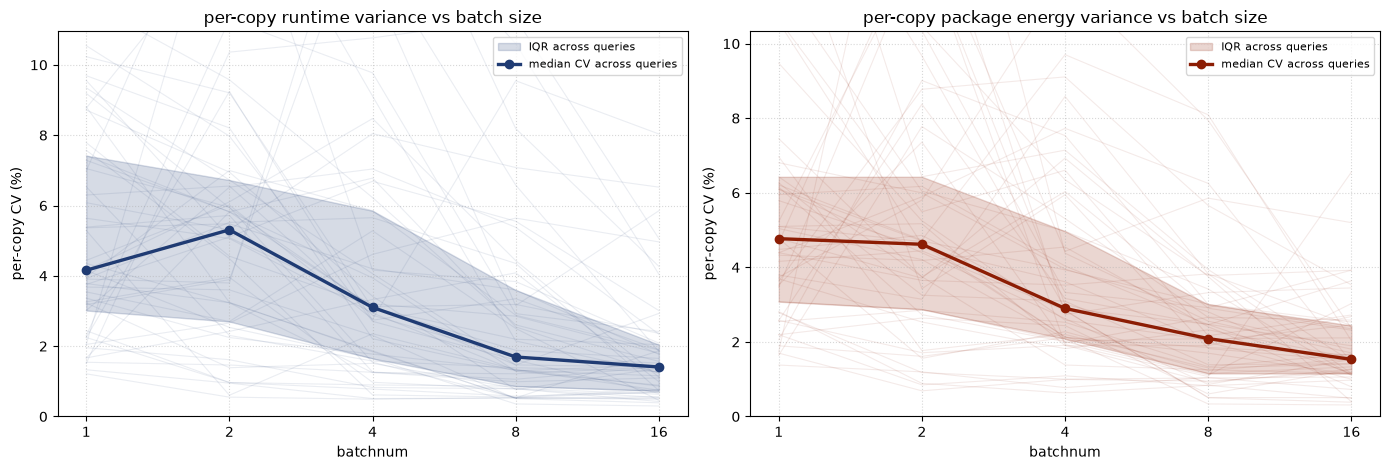

Median per-copy CV(%) by batch size (across 53 queries):
          runtime_cv%  energy_cv%
batchnum                         
1                4.16        4.77
2                5.31        4.62
4                3.10        2.90
8                1.69        2.09
16               1.41        1.53

Least reproducible queries at batchnum=1 (highest runtime CV%):
                    qid  mean_copy_s  std_copy_s  cv_pct
   q22/v2_anti_join.sql       0.2104      0.0342 16.2441
q11/v1_materialized.sql       0.1412      0.0167 11.8067
  q16/v2_not_exists.sql       0.2745      0.0289 10.5447
           q16/base.sql       0.3002      0.0307 10.2320
q05/v1_materialized.sql       0.3372      0.0327  9.6926
           q02/base.sql       0.2924      0.0279  9.5567
q03/v1_materialized.sql       0.3393      0.0317  9.3461
 q02/v2_decorrelate.sql       0.3231      0.0297  9.1893
q12/v1_materialized.sql       0.3632      0.0320  8.8026
           q22/base.sql       0.1021      0.0089  8.7684
           q0

In [55]:
import matplotlib.pyplot as plt


def variance_table(col):
    v = measured.groupby(["qid", "batchnum"]).agg(
        n=(col, "size"), mean=(col, "mean"), std=(col, "std"),
    ).reset_index()
    v["cv_pct"] = 100 * v["std"] / v["mean"]
    return v


var_t = variance_table("copy_time_s")
var_e = variance_table("copy_pkg_j")
xpos = np.arange(len(BATCH))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, (v, title, color) in zip(
        axes,
        [(var_t, "per-copy runtime", "#1f3b73"),
         (var_e, "per-copy package energy", "#8c1d04")]):
    piv = v.pivot(index="qid", columns="batchnum", values="cv_pct").reindex(columns=BATCH)
    for _, row in piv.iterrows():
        ax.plot(xpos, row.values, color=color, alpha=0.09, lw=0.8)
    q1, q3 = piv.quantile(0.25), piv.quantile(0.75)
    ax.fill_between(xpos, q1.values, q3.values, color=color, alpha=0.18,
                    label="IQR across queries")
    ax.plot(xpos, piv.median().values, color=color, marker="o", lw=2.4,
            label="median CV across queries")
    ax.set_xticks(xpos); ax.set_xticklabels(BATCH)
    ax.set_xlabel("batchnum"); ax.set_ylabel("per-copy CV (%)")
    ax.set_ylim(0, float(np.nanpercentile(piv.values, 92)) * 1.15)
    ax.set_title(f"{title} variance vs batch size")
    ax.grid(linestyle=":", alpha=0.5); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print("Median per-copy CV(%) by batch size (across {} queries):".format(
    var_t["qid"].nunique()))
tab = pd.DataFrame({
    "runtime_cv%": var_t.groupby("batchnum")["cv_pct"].median(),
    "energy_cv%": var_e.groupby("batchnum")["cv_pct"].median(),
}).round(2)
print(tab.to_string())

print("\nLeast reproducible queries at batchnum=1 (highest runtime CV%):")
top = (var_t[var_t["batchnum"] == 1].sort_values("cv_pct", ascending=False)
       .head(12)[["qid", "mean", "std", "cv_pct"]]
       .rename(columns={"mean": "mean_copy_s", "std": "std_copy_s"}))
print(top.round(4).to_string(index=False))


## 4. Task 2 — warm-up statistics per query (runtime **and** energy)

Each group runs two warm-ups before the measured step-up. We line up, per group:

* **`warmup1`** — the very first execution after the restart (coldest: cold OS
  page cache / cold buffer cache);
* **`warmup2`** — the second warm-up;
* **`warm`** — the first *measured* single run (`batchnum=1`), the representative
  steady value.

Averaging the three groups per query, `cold penalty = warmup1 / warm` is how
much heavier the first cold run is than warm, and `warmup2 / warm` says whether
**one** warm-up already reaches steady state. Everything is a **ratio**, so the
bars are on a plain linear axis (no log needed). The left panel is runtime, the
right is package energy, for the same set of queries (ranked by runtime cold
penalty) so the two levers line up.


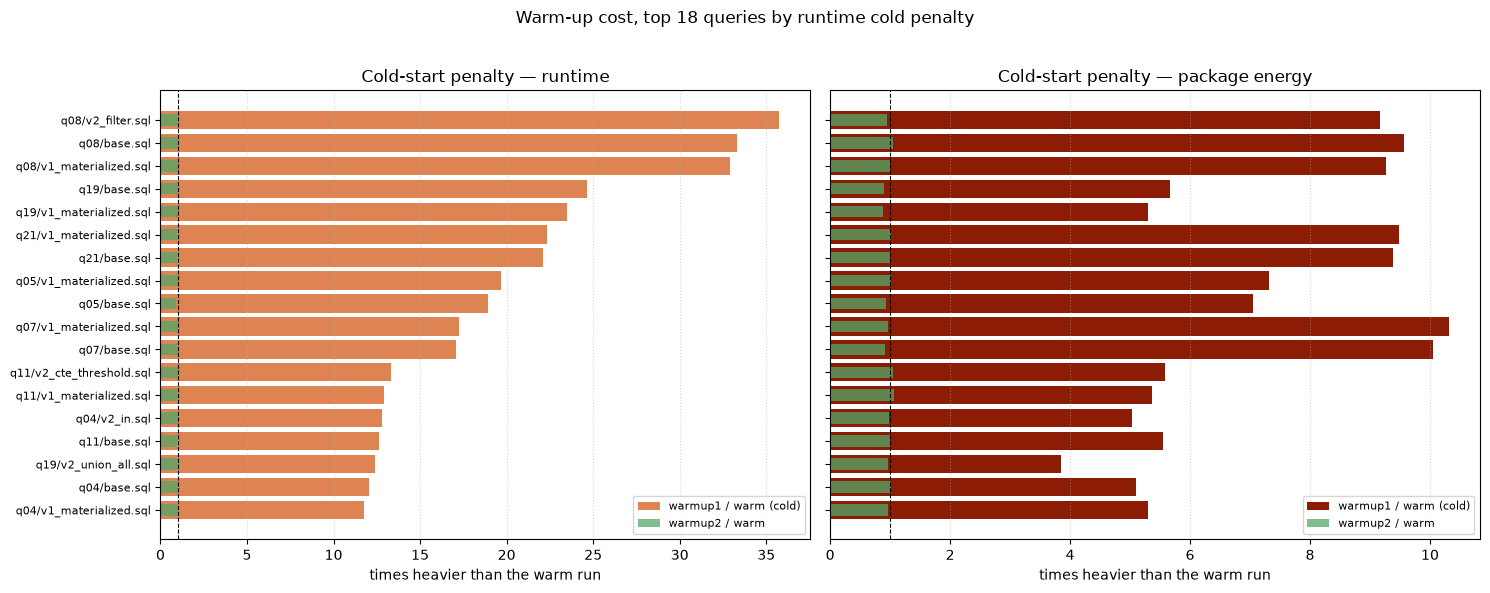

[runtime] cold penalty (warmup1/warm): median 6.06x, mean 9.26x, max 35.76x;  after 1 warm-up: median 0.98x, 52/53 queries within 5% of warm.
[energy] cold penalty (warmup1/warm): median 3.21x, mean 4.21x, max 10.32x;  after 1 warm-up: median 1.00x, 48/53 queries within 5% of warm.

Queries with the largest runtime cold penalty (with their energy penalty):
                     qid  warmup1_s  warm_s  cold_x_time  cold_x_energy
       q08/v2_filter.sql      6.997   0.196       35.757          9.159
            q08/base.sql      6.503   0.195       33.332          9.572
 q08/v1_materialized.sql      6.375   0.194       32.889          9.261
            q19/base.sql      1.819   0.074       24.657          5.672
 q19/v1_materialized.sql      1.748   0.075       23.464          5.294
 q21/v1_materialized.sql     11.942   0.535       22.306          9.489
            q21/base.sql     12.048   0.545       22.085          9.381
 q05/v1_materialized.sql      6.544   0.337       19.654         

In [56]:
def warm_summary(metric):
    w1 = (warm[warm["batch_index"] == 1]
          .set_index(["qid", "repeat"])[metric].rename("w1"))
    w2 = (warm[warm["batch_index"] == 2]
          .set_index(["qid", "repeat"])[metric].rename("w2"))
    wr = (measured[measured["batchnum"] == 1]
          .set_index(["qid", "repeat"])[metric].rename("warm"))
    m = pd.concat([w1, w2, wr], axis=1).reset_index()
    m["cold"] = m["w1"] / m["warm"]
    m["after1"] = m["w2"] / m["warm"]
    return m.groupby("qid").agg(
        w1=("w1", "mean"), w2=("w2", "mean"), warm=("warm", "mean"),
        cold=("cold", "mean"), after1=("after1", "mean")).reset_index()


# runtime uses per-copy seconds; energy uses whole-run pkg joules (batchnum=1
# rows, so rapl_pkg_j already is the per-run energy)
wq_t = warm_summary("avg_copy_elapsed_sec")
wq_e = warm_summary("rapl_pkg_j")

order = wq_t.sort_values("cold", ascending=False).head(18)["qid"].tolist()
et = wq_e.set_index("qid")
y = np.arange(len(order))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, (src, title, c_cold) in zip(
        axes,
        [(wq_t.set_index("qid"), "runtime", "#dd8452"),
         (et, "package energy", "#8c1d04")]):
    cold = [src.loc[q, "cold"] for q in order]
    after1 = [src.loc[q, "after1"] for q in order]
    ax.barh(y, cold, color=c_cold, label="warmup1 / warm (cold)")
    ax.barh(y, after1, color="#55a868", alpha=0.75, height=0.5,
            label="warmup2 / warm")
    ax.axvline(1.0, color="k", lw=0.8, ls="--")
    ax.set_xlabel("times heavier than the warm run")
    ax.set_title(f"Cold-start penalty — {title}")
    ax.grid(axis="x", linestyle=":", alpha=0.5); ax.legend(fontsize=8)
axes[0].set_yticks(y); axes[0].set_yticklabels(order, fontsize=8)
axes[0].invert_yaxis()
fig.suptitle("Warm-up cost, top 18 queries by runtime cold penalty", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

for name, wq in [("runtime", wq_t), ("energy", wq_e)]:
    near = int((wq["after1"] <= 1.05).sum())
    print(f"[{name}] cold penalty (warmup1/warm): median {wq['cold'].median():.2f}x, "
          f"mean {wq['cold'].mean():.2f}x, max {wq['cold'].max():.2f}x;  "
          f"after 1 warm-up: median {wq['after1'].median():.2f}x, "
          f"{near}/{len(wq)} queries within 5% of warm.")

print("\nQueries with the largest runtime cold penalty (with their energy penalty):")
merged = wq_t[["qid", "w1", "warm", "cold"]].rename(
    columns={"w1": "warmup1_s", "warm": "warm_s", "cold": "cold_x_time"})
merged = merged.merge(
    wq_e[["qid", "cold"]].rename(columns={"cold": "cold_x_energy"}), on="qid")
print(merged.sort_values("cold_x_time", ascending=False).head(12)
      .round(3).to_string(index=False))


## 5. Task 3 — line of best fit: per-run cost (slope) vs fixed overhead (intercept)

For each query, plot the **whole-batch** quantity against `batchnum`, pooling all
three groups (up to 15 points), and fit an ordinary least-squares line

`y ≈ overhead + slope · batchnum`,   with `y = elapsed_sec` (runtime) or `y = rapl_pkg_j` (energy).

Because a batch just runs the same warm query `batchnum` times back-to-back, the
**slope** is the marginal **cost of one warm run** (seconds, or joules) and the
**y-intercept** (`batchnum → 0`) is the fixed **overhead** paid once per batch.
`R²` says how linear the step-up is. Both axes are linear — the whole point is
that the relationship *is* a straight line in `batchnum`.

The first figure is one representative query, runtime and energy side by side,
with the slope and intercept marked. Then a grid fits every query (runtime, then
energy), and finally the fixed overhead is summarised as a **fraction of one
run's cost** (linear) with the full fit table.


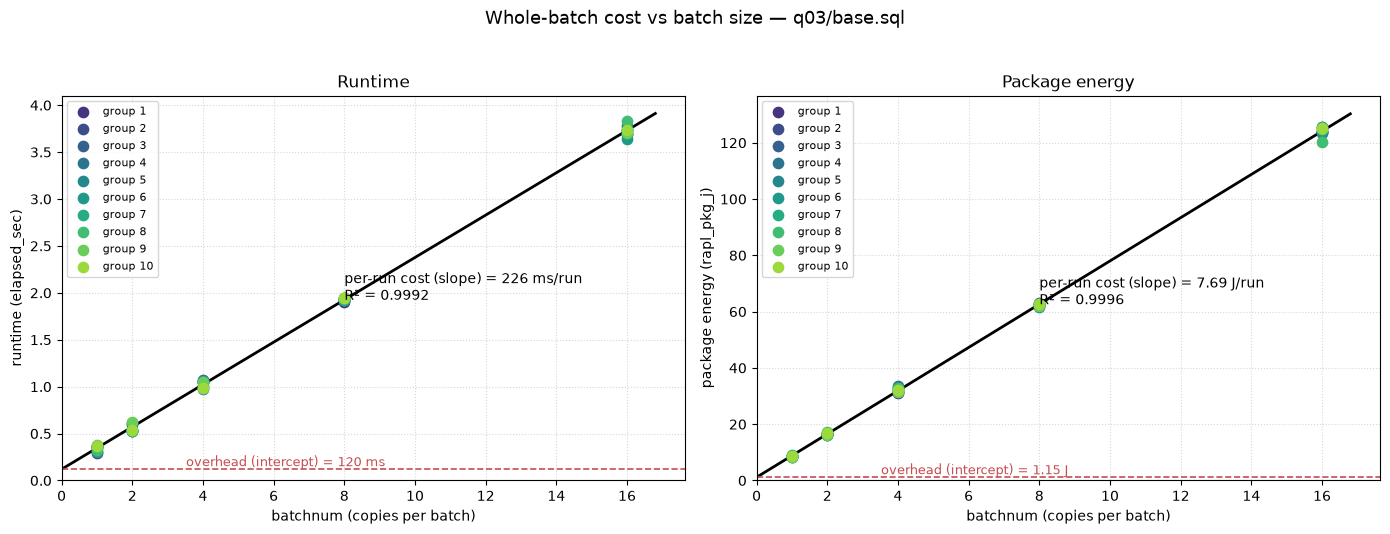

Headline query: q03/base.sql
  runtime: 225.7 ms/run, overhead 120.3 ms, R²=0.9992
  energy : 7.69 J/run, overhead 1.15 J, R²=0.9996


In [57]:
def fit_line(d, ycol):
    x = d["batchnum"].to_numpy(float)
    y = d[ycol].to_numpy(float)
    ok = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[ok], y[ok]
    if len(x) < 2 or np.ptp(x) == 0:
        return None
    slope, intercept = np.polyfit(x, y, 1)
    yhat = intercept + slope * x
    ss_res = float(((y - yhat) ** 2).sum())
    ss_tot = float(((y - y.mean()) ** 2).sum())
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return slope, intercept, r2, len(x)


def fit_all(ycol):
    rows = []
    for qid, d in measured.groupby("qid"):
        res = fit_line(d, ycol)
        if res is None:
            continue
        rows.append(dict(qid=qid, slope=res[0], overhead=res[1],
                         r2=res[2], n=res[3]))
    return pd.DataFrame(rows)


fit_t = fit_all("elapsed_sec")     # runtime: slope s/run, overhead s
fit_e = fit_all("rapl_pkg_j")      # energy:  slope J/run, overhead J

# a *typical* clearly-linear query (median runtime per-run cost, positive
# overhead) so the slope and a visible positive intercept both read off the plot
cand = fit_t[(fit_t["r2"] > 0.99) & (fit_t["overhead"] > 0)].copy()
if len(cand):
    med = cand["slope"].median()
    head_qid = cand.loc[(cand["slope"] - med).abs().idxmin(), "qid"]
else:
    head_qid = fit_t.iloc[len(fit_t) // 2]["qid"]

d = measured[measured["qid"] == head_qid]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, NREP))
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for ax, (fitdf, ycol, unit, scale, nice) in zip(
        axes,
        [(fit_t, "elapsed_sec", "ms", 1000, "runtime (elapsed_sec)"),
         (fit_e, "rapl_pkg_j", "J", 1, "package energy (rapl_pkg_j)")]):
    r = fitdf[fitdf["qid"] == head_qid].iloc[0]
    slope, intercept, r2 = r["slope"], r["overhead"], r["r2"]
    for rp, g in d.groupby("repeat"):
        ax.scatter(g["batchnum"], g[ycol], s=55, color=colors[int(rp) - 1],
                   label=f"group {int(rp)}", zorder=3)
    xs = np.linspace(0, max(BATCH) * 1.05, 100)
    ax.plot(xs, intercept + slope * xs, "k-", lw=2)
    ax.axhline(intercept, color="#c44e52", ls="--", lw=1.2)
    u = f"{intercept * scale:.0f} {unit}" if scale != 1 else f"{intercept:.2f} {unit}"
    su = f"{slope * scale:.0f} {unit}/run" if scale != 1 else f"{slope:.2f} {unit}/run"
    ax.annotate(f"overhead (intercept) = {u}", xy=(0, intercept),
                xytext=(max(BATCH) * 0.22, intercept), color="#c44e52",
                fontsize=9, va="bottom")
    ax.annotate(f"per-run cost (slope) = {su}\nR² = {r2:.4f}",
                xy=(max(BATCH) * 0.5, intercept + slope * max(BATCH) * 0.5),
                fontsize=10)
    ax.set_xlim(left=0); ax.set_ylim(bottom=0)
    ax.set_xlabel("batchnum (copies per batch)")
    ax.set_ylabel(nice)
    ax.set_title(nice.split(" (")[0].capitalize())
    ax.grid(linestyle=":", alpha=0.5); ax.legend(fontsize=8)
fig.suptitle(f"Whole-batch cost vs batch size — {head_qid}", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

rt = fit_t[fit_t["qid"] == head_qid].iloc[0]
en = fit_e[fit_e["qid"] == head_qid].iloc[0]
print(f"Headline query: {head_qid}")
print(f"  runtime: {rt['slope']*1000:.1f} ms/run, overhead {rt['overhead']*1000:.1f} ms, R²={rt['r2']:.4f}")
print(f"  energy : {en['slope']:.2f} J/run, overhead {en['overhead']:.2f} J, R²={en['r2']:.4f}")


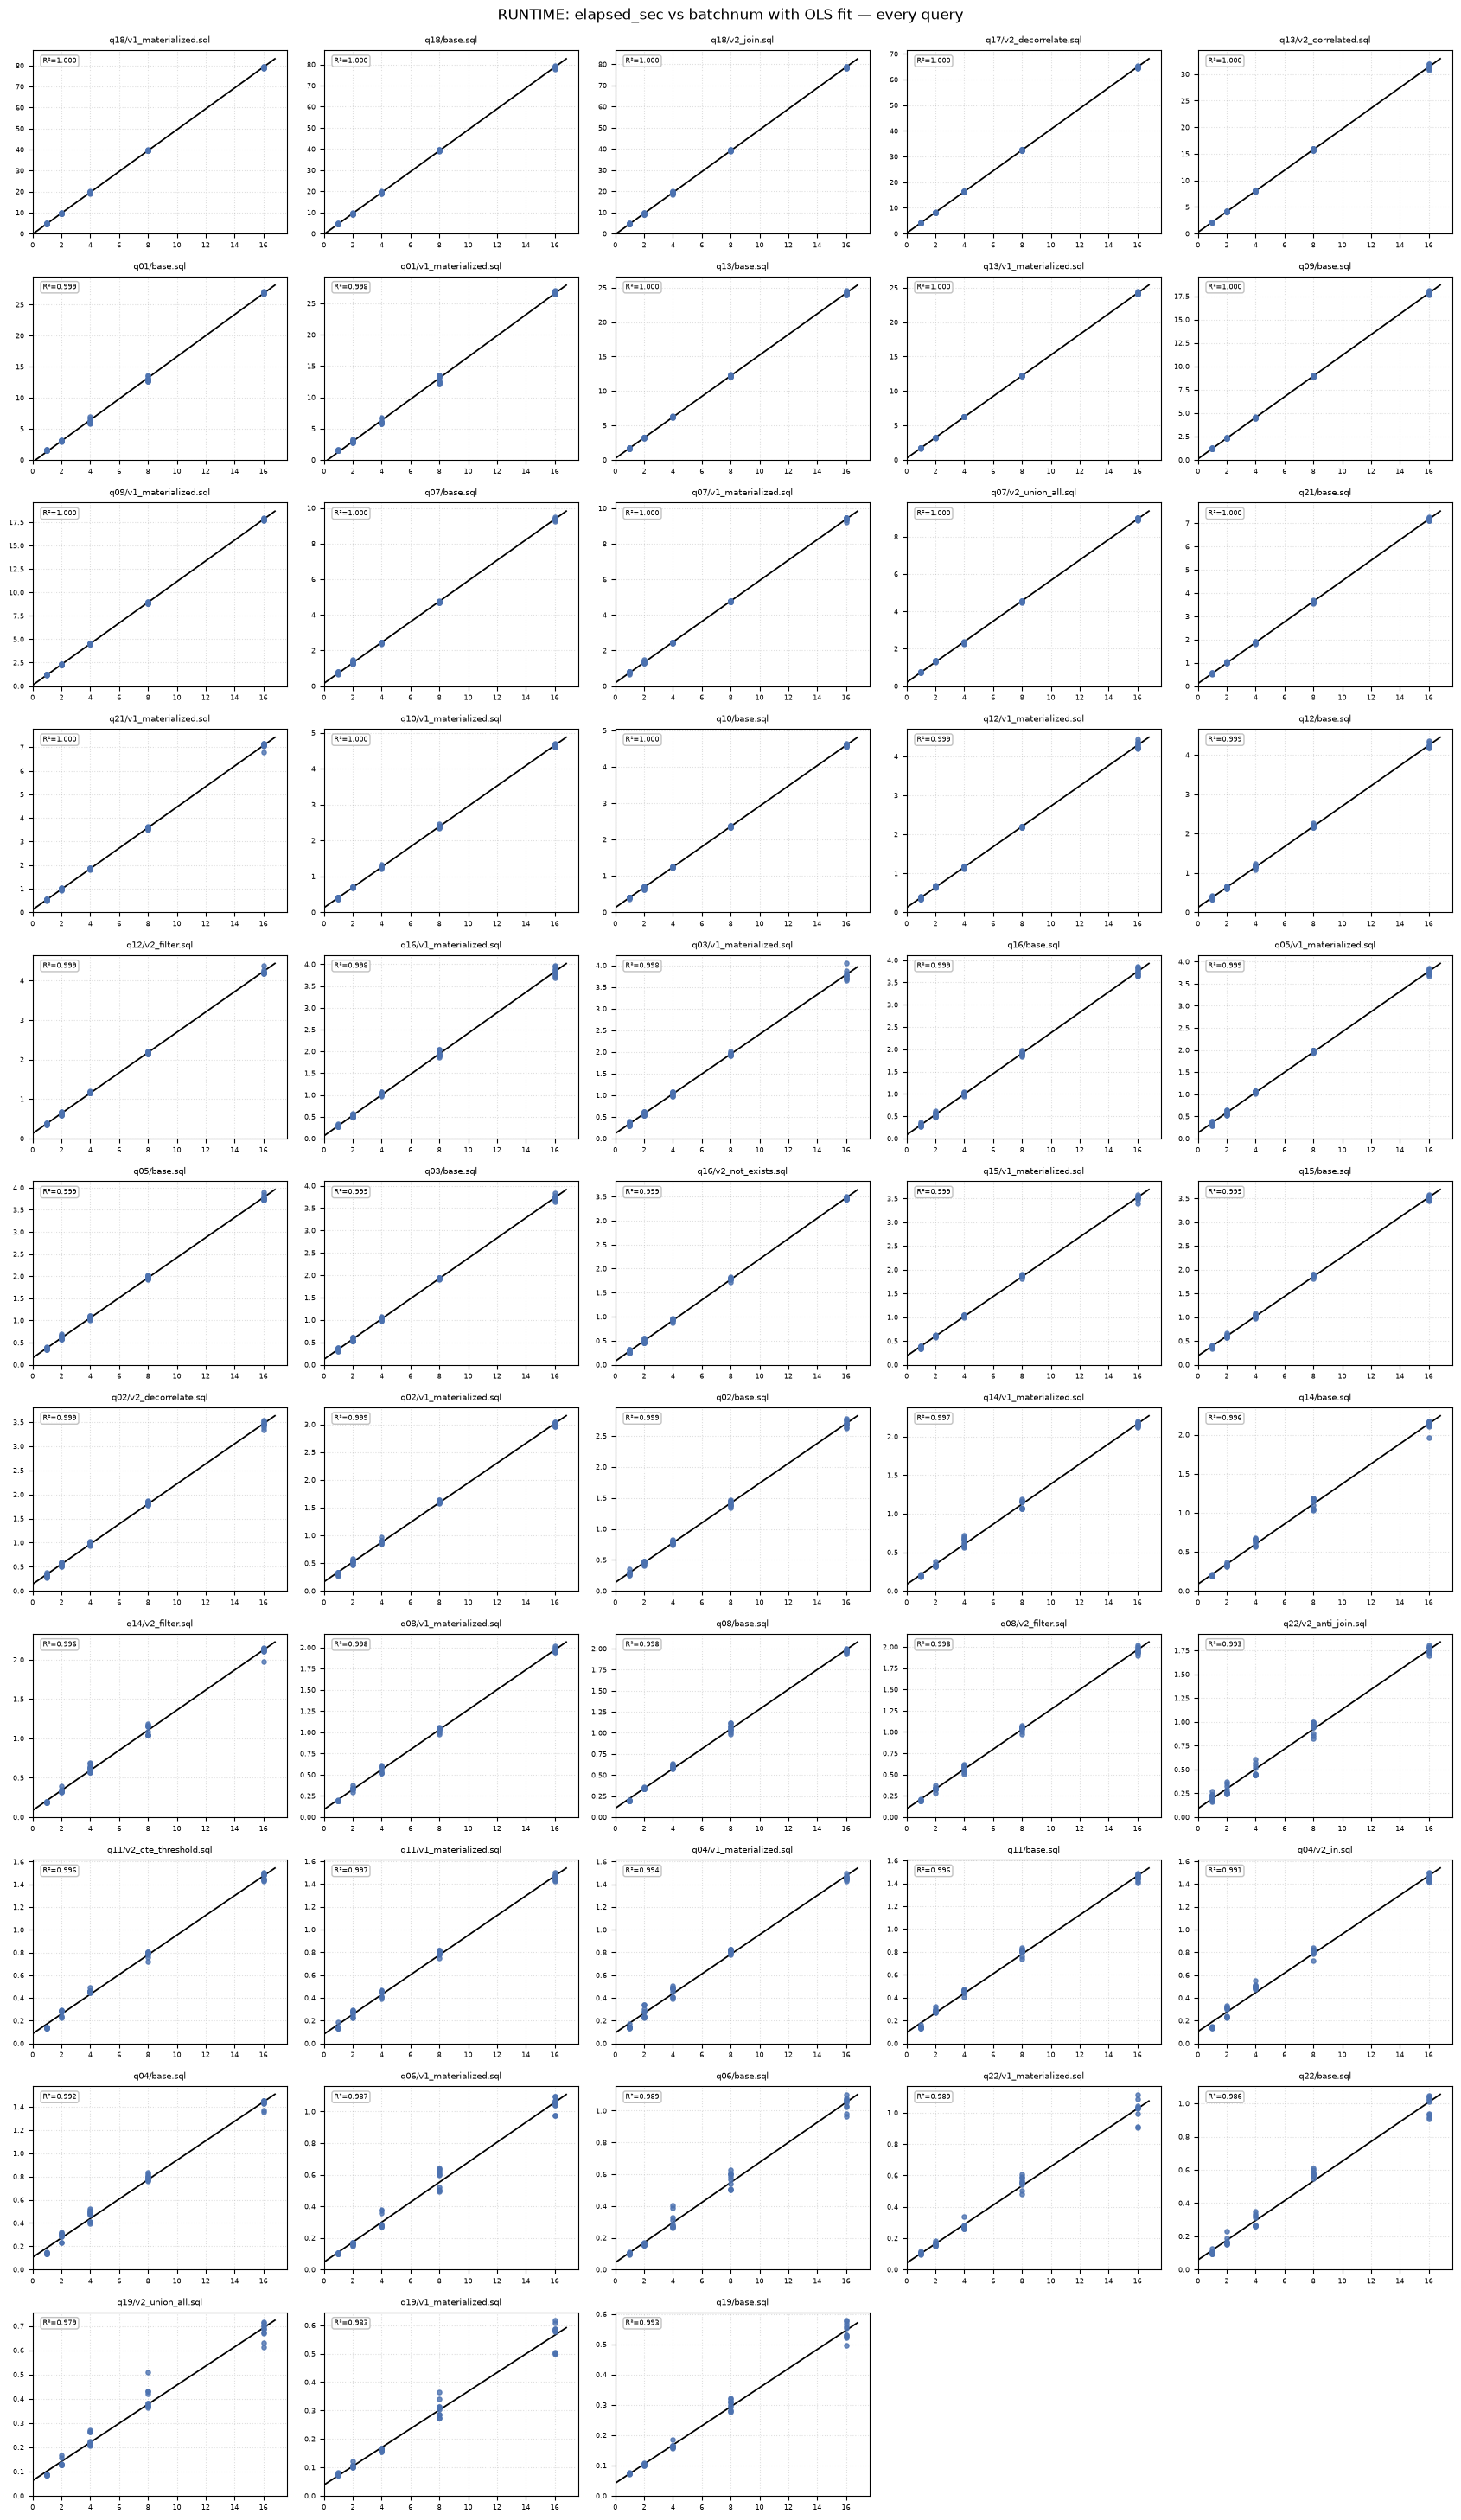

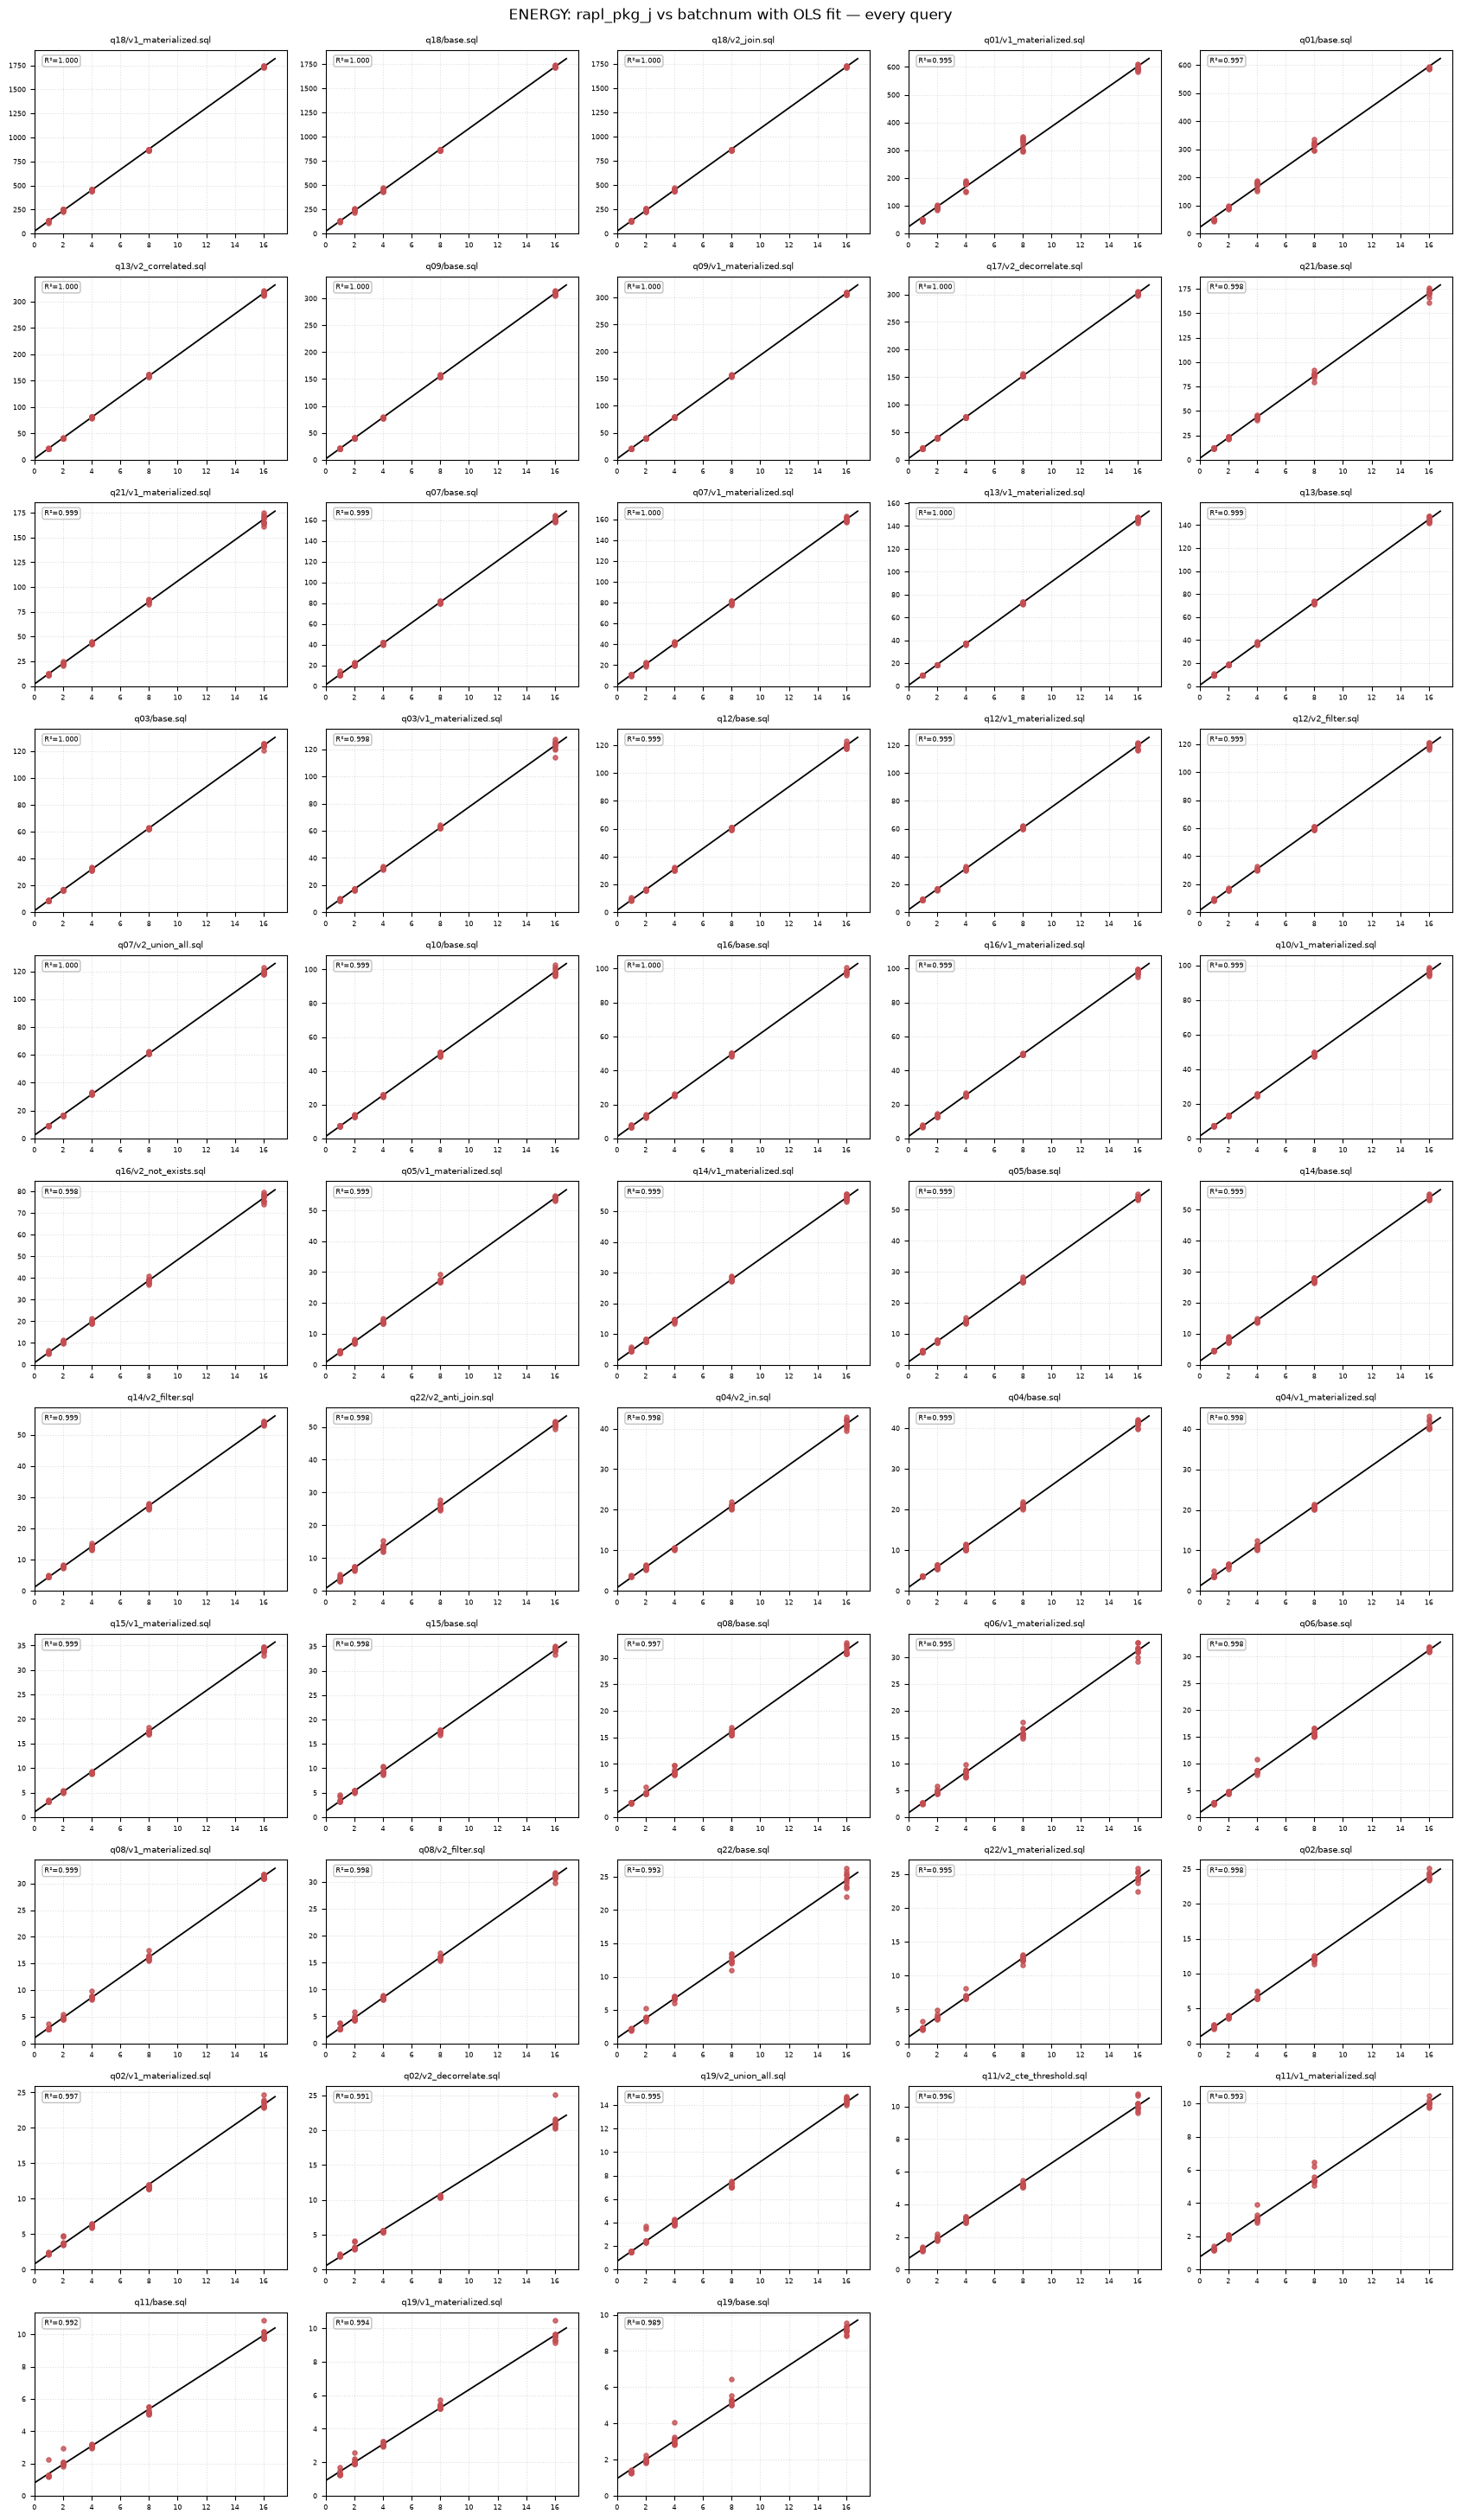

In [58]:
def draw_grid(fitdf, ycol, dot, title):
    order = fitdf.sort_values("slope", ascending=False)["qid"].tolist()
    ncols = 5
    nrows = int(np.ceil(len(order) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.4, nrows * 2.7))
    axes = np.atleast_1d(axes).ravel()
    xs = np.linspace(0, max(BATCH) * 1.05, 50)
    for ax, qid in zip(axes, order):
        d = measured[measured["qid"] == qid]
        r = fitdf[fitdf["qid"] == qid].iloc[0]
        ax.scatter(d["batchnum"], d[ycol], s=14, color=dot, alpha=0.8, zorder=3)
        ax.plot(xs, r["overhead"] + r["slope"] * xs, "k-", lw=1.3)
        ax.set_title(qid, fontsize=7)
        ax.set_xlim(left=0); ax.set_ylim(bottom=0)
        ax.tick_params(labelsize=6)
        ax.text(0.04, 0.96, f"R²={r['r2']:.3f}", transform=ax.transAxes,
                fontsize=6, va="top",
                bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.8))
        ax.grid(linestyle=":", alpha=0.4)
    for ax in axes[len(order):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.985]); plt.show()


draw_grid(fit_t, "elapsed_sec", "#4c72b0",
          "RUNTIME: elapsed_sec vs batchnum with OLS fit — every query")
draw_grid(fit_e, "rapl_pkg_j", "#c44e52",
          "ENERGY: rapl_pkg_j vs batchnum with OLS fit — every query")


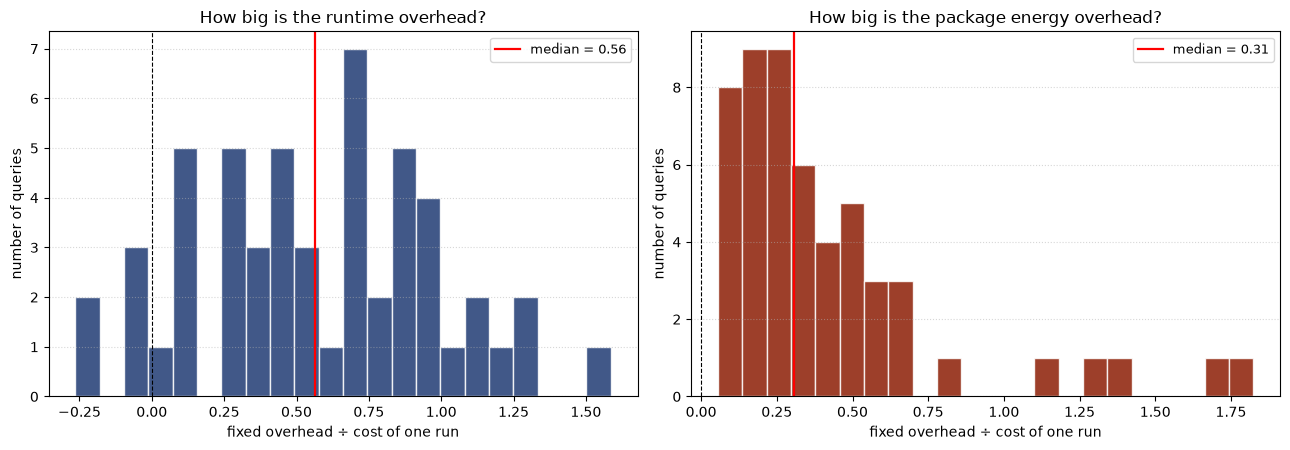

runtime: 5 queries have a small negative intercept; median R² = 0.9989
energy : 0 queries have a small negative intercept; median R² = 0.9986
per-run cost: runtime median 225.7 ms; energy median 3.33 J
overhead: runtime median 96.7 ms; energy median 1.03 J

Full fit table (sorted by runtime per-run cost):
                     qid  run_cost_ms  run_ovh_ms  run_r2  en_cost_j  en_ovh_j  en_r2
 q18/v1_materialized.sql       4965.8      -235.5  0.9999     106.82     24.28 0.9998
            q18/base.sql       4940.4      -342.9  0.9999     106.17     22.95 0.9997
         q18/v2_join.sql       4934.5      -359.2  0.9999     105.91     24.74 0.9997
  q17/v2_decorrelate.sql       4042.9       175.1  0.9999      18.75      2.22 0.9999
   q13/v2_correlated.sql       1943.5       249.3  0.9997      19.61      2.11 0.9998
            q01/base.sql       1696.7      -372.5  0.9991      35.78     22.21 0.9971
 q01/v1_materialized.sql       1688.7      -446.0  0.9984      36.10     24.22 0.9949
     

In [59]:
# ---- summary: fixed overhead as a fraction of one run's cost (linear) ----
fit_t["ovh_frac"] = fit_t["overhead"] / fit_t["slope"]
fit_e["ovh_frac"] = fit_e["overhead"] / fit_e["slope"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, (f, title, color) in zip(
        axes,
        [(fit_t, "runtime", "#1f3b73"), (fit_e, "package energy", "#8c1d04")]):
    vals = f["ovh_frac"].clip(-0.5, 2.5)
    ax.hist(vals, bins=22, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.axvline(f["ovh_frac"].median(), color="red", lw=1.6,
               label=f"median = {f['ovh_frac'].median():.2f}")
    ax.set_xlabel("fixed overhead ÷ cost of one run")
    ax.set_ylabel("number of queries")
    ax.set_title(f"How big is the {title} overhead?")
    ax.grid(axis="y", linestyle=":", alpha=0.5); ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

print(f"runtime: {(fit_t['overhead'] < 0).sum()} queries have a small negative "
      f"intercept; median R² = {fit_t['r2'].median():.4f}")
print(f"energy : {(fit_e['overhead'] < 0).sum()} queries have a small negative "
      f"intercept; median R² = {fit_e['r2'].median():.4f}")
print(f"per-run cost: runtime median {fit_t['slope'].median()*1000:.1f} ms; "
      f"energy median {fit_e['slope'].median():.2f} J")
print(f"overhead: runtime median {fit_t['overhead'].median()*1000:.1f} ms; "
      f"energy median {fit_e['overhead'].median():.2f} J")

comb = fit_t[["qid", "slope", "overhead", "r2"]].rename(
    columns={"slope": "run_cost_s", "overhead": "run_ovh_s", "r2": "run_r2"})
comb = comb.merge(fit_e[["qid", "slope", "overhead", "r2"]].rename(
    columns={"slope": "en_cost_j", "overhead": "en_ovh_j", "r2": "en_r2"}), on="qid")
comb["run_cost_ms"] = (comb["run_cost_s"] * 1000).round(1)
comb["run_ovh_ms"] = (comb["run_ovh_s"] * 1000).round(1)
comb["en_cost_j"] = comb["en_cost_j"].round(2)
comb["en_ovh_j"] = comb["en_ovh_j"].round(2)
comb["run_r2"] = comb["run_r2"].round(4)
comb["en_r2"] = comb["en_r2"].round(4)
print("\nFull fit table (sorted by runtime per-run cost):")
print(comb.sort_values("run_cost_ms", ascending=False)[
    ["qid", "run_cost_ms", "run_ovh_ms", "run_r2",
     "en_cost_j", "en_ovh_j", "en_r2"]].to_string(index=False))


## 6. Fit residuals vs `batchnum` — relative (% of fitted)

Sections 6–6d are the residual diagnostics for the §5 fits. **§6** and **§6b**
plot the residual against `batchnum`; **§6c** and **§6d** plot it against the
run's fitted **time** (seconds) — a common axis for both metrics. Each pair comes
in a **relative** (% of fitted) and an **absolute** (raw s / J) flavour.

A straight line is only the right model if its **residuals** (`observed −
fitted`) are unstructured. Here we take every measured point, subtract the
per-query fit from §5, and express the residual as a **percentage of the fitted
value** so all queries — which span several orders of magnitude per run — sit on
the same axis. We do this for runtime and package energy.

Reading the plot: points scattered symmetrically around **0** at every batch
size means the line fits well; a consistent **curve** (e.g. all-positive at the
ends and negative in the middle, or vice-versa) would signal that cost is *not*
quite linear in `batchnum`; and a **funnel** that narrows as `batchnum` grows is
the same noise-averaging effect seen in the variance sections. The box shows the
inter-quartile range per batch size (whiskers 5–95%), with the raw points
jittered behind it.


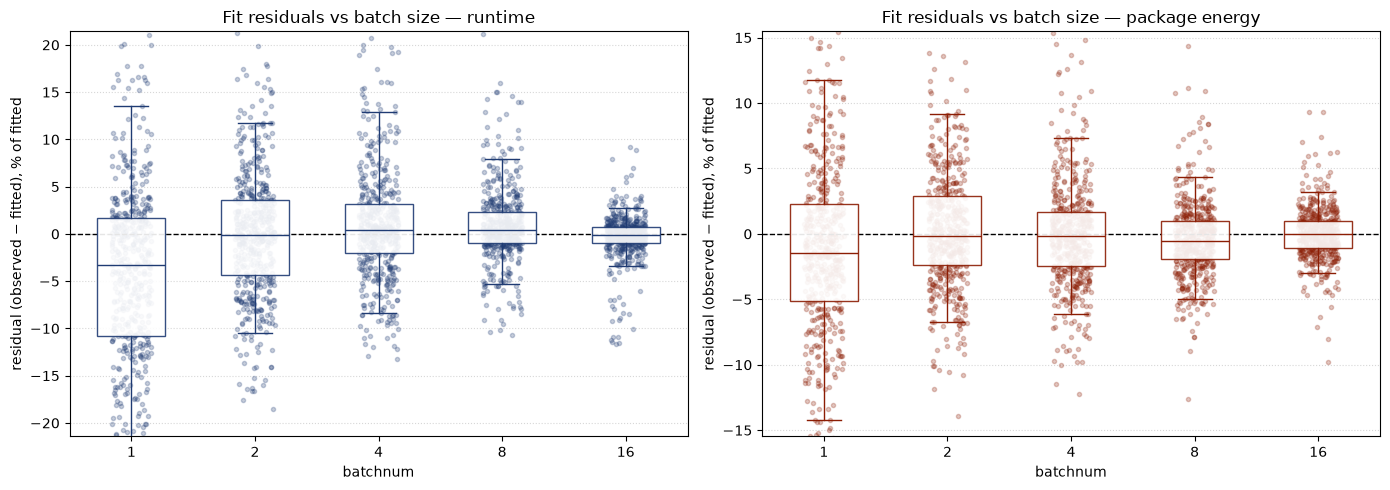

Median residual (% of fitted) by batch size — a systematic sign here would mean the fit is slightly non-linear:
          runtime_%  energy_%
batchnum                     
1             -3.33     -1.44
2             -0.06     -0.15
4              0.46     -0.15
8              0.39     -0.53
16            -0.15     -0.01

Residual spread (std of % residual) by batch size:
          runtime_%  energy_%
batchnum                     
1             10.59      8.94
2              6.96      7.07
4              6.33      4.73
8              4.16      3.24
16             2.39      2.17


In [60]:
rng = np.random.default_rng(0)


def residual_frame(fitdf, ycol):
    f = fitdf.set_index("qid")
    d = measured.dropna(subset=[ycol]).copy()
    d = d[d["qid"].isin(f.index)]
    yhat = (f.loc[d["qid"], "overhead"].to_numpy()
            + f.loc[d["qid"], "slope"].to_numpy() * d["batchnum"].to_numpy())
    d["yhat"] = yhat
    d["rel_resid_pct"] = 100 * (d[ycol] - d["yhat"]) / d["yhat"]
    return d


res_t = residual_frame(fit_t, "elapsed_sec")
res_e = residual_frame(fit_e, "rapl_pkg_j")
pos = {b: i for i, b in enumerate(BATCH)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (res, title, color) in zip(
        axes, [(res_t, "runtime", "#1f3b73"),
                (res_e, "package energy", "#8c1d04")]):
    xi = res["batchnum"].map(pos).to_numpy(float)
    ax.scatter(xi + rng.uniform(-0.16, 0.16, len(xi)), res["rel_resid_pct"],
               s=9, color=color, alpha=0.25, zorder=2)
    box = [res.loc[res["batchnum"] == b, "rel_resid_pct"].values for b in BATCH]
    bp = ax.boxplot(box, positions=range(len(BATCH)), widths=0.55,
                    whis=(5, 95), showfliers=False, patch_artist=True, zorder=3)
    for patch in bp["boxes"]:
        patch.set(facecolor="white", edgecolor=color, alpha=0.9)
    for el in ("whiskers", "caps", "medians"):
        for ln in bp[el]:
            ln.set_color(color)
    ax.axhline(0, color="k", lw=1.0, ls="--")
    ax.set_xticks(range(len(BATCH))); ax.set_xticklabels(BATCH)
    lim = float(np.nanpercentile(np.abs(res["rel_resid_pct"]), 97))
    ax.set_ylim(-lim * 1.1, lim * 1.1)
    ax.set_xlabel("batchnum")
    ax.set_ylabel("residual (observed − fitted), % of fitted")
    ax.set_title(f"Fit residuals vs batch size — {title}")
    ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

print("Median residual (% of fitted) by batch size — a systematic sign here "
      "would mean the fit is slightly non-linear:")
tab = pd.DataFrame({
    "runtime_%": res_t.groupby("batchnum")["rel_resid_pct"].median(),
    "energy_%": res_e.groupby("batchnum")["rel_resid_pct"].median(),
}).round(2)
print(tab.to_string())
print("\nResidual spread (std of % residual) by batch size:")
tab2 = pd.DataFrame({
    "runtime_%": res_t.groupby("batchnum")["rel_resid_pct"].std(),
    "energy_%": res_e.groupby("batchnum")["rel_resid_pct"].std(),
}).round(2)
print(tab2.to_string())


## 6b. Fit residuals vs `batchnum` — absolute (raw s / J)

The same residuals as §6, but in their **raw units** — `observed − fitted` in
**seconds** (runtime) and **joules** (energy) — so you see the actual size of the
miss, not just its relative size. Because queries span 3+ orders of magnitude (a
tiny query's residuals are milliseconds, `q02`'s are seconds) the y-axis is
**symlog** (linear near zero, log further out), the only way to show both scales
while keeping the sign. Note the box **grows** with `batchnum` here, the opposite
of the §6 percentage view — a bigger batch is simply a bigger number, the
magnitude effect §9 pins down.


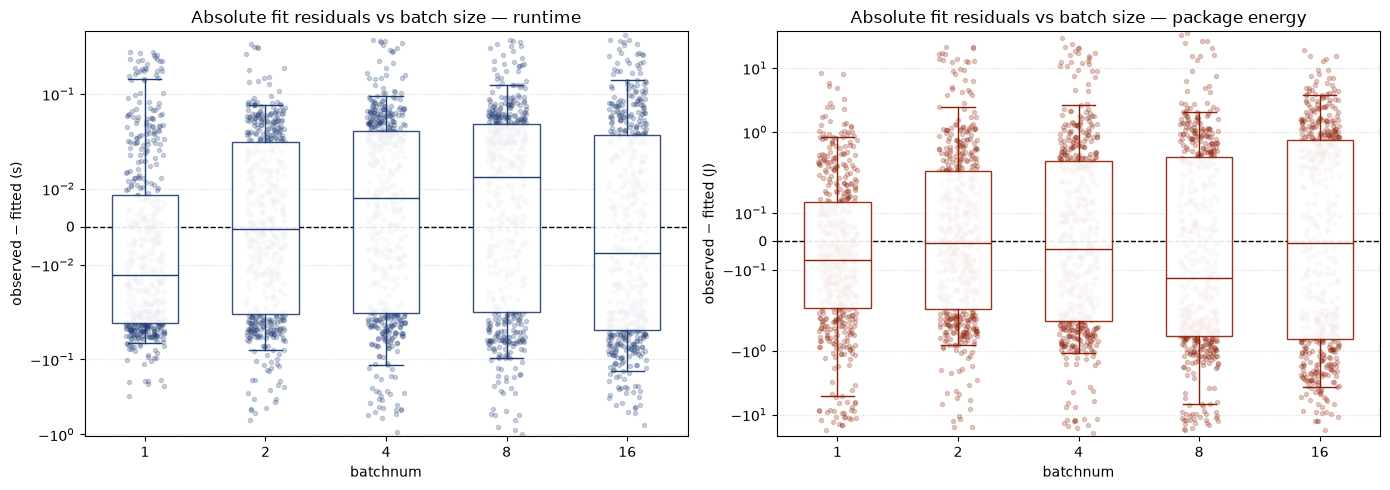

Absolute residual size (median |observed − fitted|) by batch size — grows with the batch because the whole-batch value grows:
          runtime |resid| (s)  energy |resid| (J)
batchnum                                         
1                      0.0232              0.1936
2                      0.0242              0.2478
4                      0.0289              0.3471
8                      0.0309              0.5024
16                     0.0345              0.7063


In [61]:
ar_t = res_t.assign(abs_resid=res_t["elapsed_sec"] - res_t["yhat"])   # seconds
ar_e = res_e.assign(abs_resid=res_e["rapl_pkg_j"] - res_e["yhat"])    # joules

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (ar, title, color, unit) in zip(
        axes, [(ar_t, "runtime", "#1f3b73", "s"),
                (ar_e, "package energy", "#8c1d04", "J")]):
    xi = ar["batchnum"].map(pos).to_numpy(float)
    ax.scatter(xi + rng.uniform(-0.16, 0.16, len(xi)), ar["abs_resid"],
               s=9, color=color, alpha=0.22, zorder=2)
    box = [ar.loc[ar["batchnum"] == b, "abs_resid"].values for b in BATCH]
    bp = ax.boxplot(box, positions=range(len(BATCH)), widths=0.55,
                    whis=(5, 95), showfliers=False, patch_artist=True, zorder=3)
    for patch in bp["boxes"]:
        patch.set(facecolor="white", edgecolor=color, alpha=0.9)
    for el in ("whiskers", "caps", "medians"):
        for ln in bp[el]:
            ln.set_color(color)
    ax.axhline(0, color="k", lw=1.0, ls="--")
    lt = float(np.nanpercentile(np.abs(ar["abs_resid"]), 40)) or 1e-4
    ax.set_yscale("symlog", linthresh=lt)
    ax.set_xticks(range(len(BATCH))); ax.set_xticklabels(BATCH)
    ax.set_xlabel("batchnum")
    ax.set_ylabel(f"observed − fitted ({unit})")
    ax.set_title(f"Absolute fit residuals vs batch size — {title}")
    ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

print("Absolute residual size (median |observed − fitted|) by batch size — "
      "grows with the batch because the whole-batch value grows:")
tab = pd.DataFrame({
    "runtime |resid| (s)": ar_t.assign(a=ar_t["abs_resid"].abs())
        .groupby("batchnum")["a"].median(),
    "energy |resid| (J)": ar_e.assign(a=ar_e["abs_resid"].abs())
        .groupby("batchnum")["a"].median(),
}).round(4)
print(tab.to_string())


## 6c. Fit residuals vs the run's time — relative (% of fitted)

Now the x-axis is the run's **fitted whole-batch time** (seconds) rather than the
discrete `batchnum` — and the **same time axis is used for both panels**, so the
runtime- and energy-residuals line up against how long the run took (energy uses
fitted time, not fitted joules, on x). Each point is one measured batch, coloured
by `batchnum`; time is on a log x-axis because it spans orders. A flat, symmetric
band around **0** means the relative error is time-independent; a funnel narrowing
to the right would mean longer runs are relatively tighter.


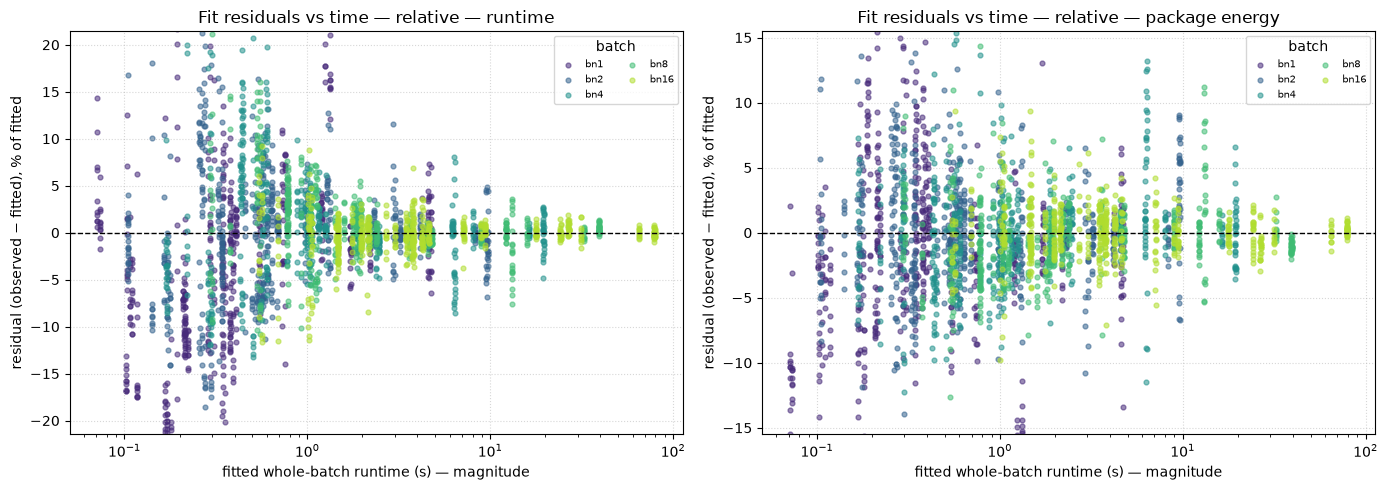

In [62]:
colB = plt.cm.viridis(np.linspace(0.12, 0.88, len(BATCH)))
ft = fit_t.set_index("qid")     # fitted runtime supplies the common time x-axis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (res, title) in zip(
        axes, [(res_t, "runtime"), (res_e, "package energy")]):
    d = res.copy()
    d["mag_s"] = (ft.loc[d["qid"], "overhead"].to_numpy()
                  + ft.loc[d["qid"], "slope"].to_numpy() * d["batchnum"].to_numpy())
    d = d[d["mag_s"] > 0]
    for j, b in enumerate(BATCH):
        s = d[d["batchnum"] == b]
        ax.scatter(s["mag_s"], s["rel_resid_pct"], s=12, color=colB[j],
                   alpha=0.55, label=f"bn{b}")
    ax.axhline(0, color="k", lw=1.0, ls="--")
    ax.set_xscale("log")
    lim = float(np.nanpercentile(np.abs(d["rel_resid_pct"]), 97))
    ax.set_ylim(-lim * 1.1, lim * 1.1)
    ax.set_xlabel("fitted whole-batch runtime (s) — magnitude")
    ax.set_ylabel("residual (observed − fitted), % of fitted")
    ax.set_title(f"Fit residuals vs time — relative — {title}")
    ax.grid(linestyle=":", alpha=0.5)
    ax.legend(fontsize=7, title="batch", ncol=2)
fig.tight_layout(); plt.show()


## 6d. Fit residuals vs the run's time — absolute (raw s / J)

The same as §6c but in raw units, with a **symlog** y-axis, again against the
run's fitted **time** (seconds) on both panels. This is the direct picture of
**heteroscedasticity**: if the cloud fans out to the right, the absolute error
grows with how long the run takes. The printed slope is `log|residual|` regressed
on `log(fitted time)` — a value near 1 means the absolute error is roughly
proportional to run time (constant relative error), the same conclusion §9
reaches for the variance.


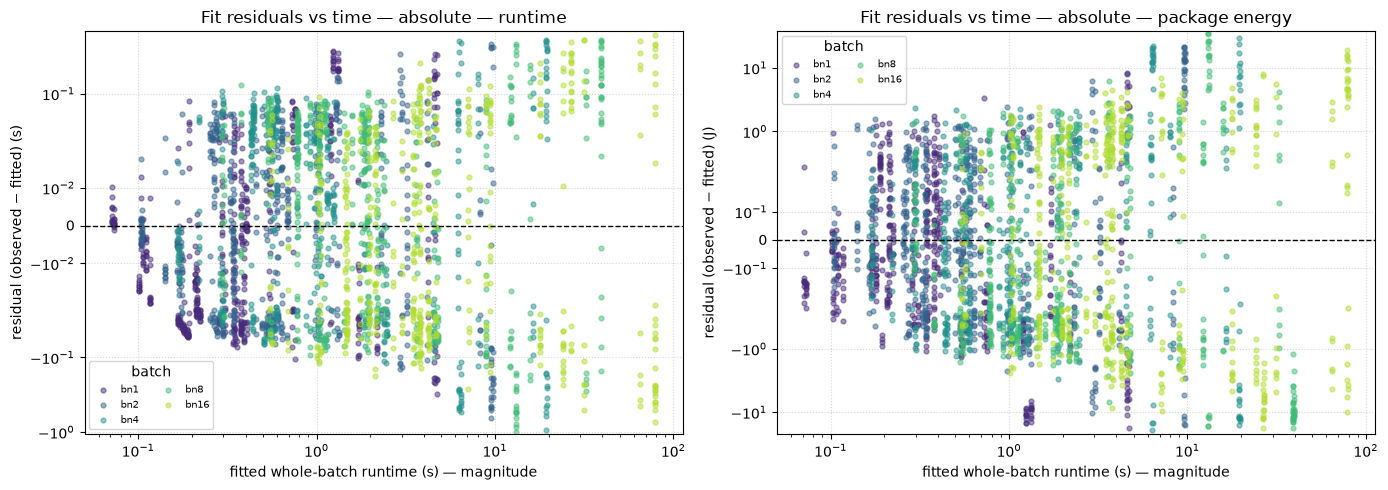

Heteroscedasticity slope  d(log|residual|)/d(log fitted-time)  (~1 = absolute error proportional to run time):
  runtime: 0.40
  energy: 0.63


In [63]:
colB = plt.cm.viridis(np.linspace(0.12, 0.88, len(BATCH)))
ft = fit_t.set_index("qid")     # fitted runtime supplies the common time x-axis


def _with_time(ar):
    d = ar.copy()
    d["mag_s"] = (ft.loc[d["qid"], "overhead"].to_numpy()
                  + ft.loc[d["qid"], "slope"].to_numpy() * d["batchnum"].to_numpy())
    return d[d["mag_s"] > 0]


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (ar, title, unit) in zip(
        axes, [(ar_t, "runtime", "s"), (ar_e, "package energy", "J")]):
    d = _with_time(ar)
    for j, b in enumerate(BATCH):
        s = d[d["batchnum"] == b]
        ax.scatter(s["mag_s"], s["abs_resid"], s=12, color=colB[j],
                   alpha=0.5, label=f"bn{b}")
    ax.axhline(0, color="k", lw=1.0, ls="--")
    ax.set_xscale("log")
    lt = float(np.nanpercentile(np.abs(d["abs_resid"]), 40)) or 1e-4
    ax.set_yscale("symlog", linthresh=lt)
    ax.set_xlabel("fitted whole-batch runtime (s) — magnitude")
    ax.set_ylabel(f"residual (observed − fitted) ({unit})")
    ax.set_title(f"Fit residuals vs time — absolute — {title}")
    ax.grid(linestyle=":", alpha=0.5)
    ax.legend(fontsize=7, title="batch", ncol=2)
fig.tight_layout(); plt.show()

print("Heteroscedasticity slope  d(log|residual|)/d(log fitted-time)  "
      "(~1 = absolute error proportional to run time):")
for ar, name in [(ar_t, "runtime"), (ar_e, "energy")]:
    d = _with_time(ar)
    x = np.log10(d["mag_s"].to_numpy())
    y = np.log10(d["abs_resid"].abs().replace(0, np.nan).to_numpy())
    ok = np.isfinite(x) & np.isfinite(y)
    slope = np.polyfit(x[ok], y[ok], 1)[0]
    print(f"  {name}: {slope:.2f}")


## 7. Variance vs test length — does runtime drive the noise?

Each point is one `(query, batchnum)`: its **per-copy CV%** (the run-to-run
spread from §3) on the y-axis against the **mean per-copy runtime** — the test
length — on the x-axis, coloured by `batchnum`. **Energy is an outcome**, so its
variance is also shown against **runtime**, not against energy: the right panel is
energy CV vs runtime. This asks whether the fast, tiny queries are the noisy ones
(fixed timer / scheduling jitter being a big fraction of a small number) while the
long queries are relatively steady. The x-axis is clipped to the bulk so the
dense region is readable — a few very long queries sit far right with low CV and
are off-scale by design.


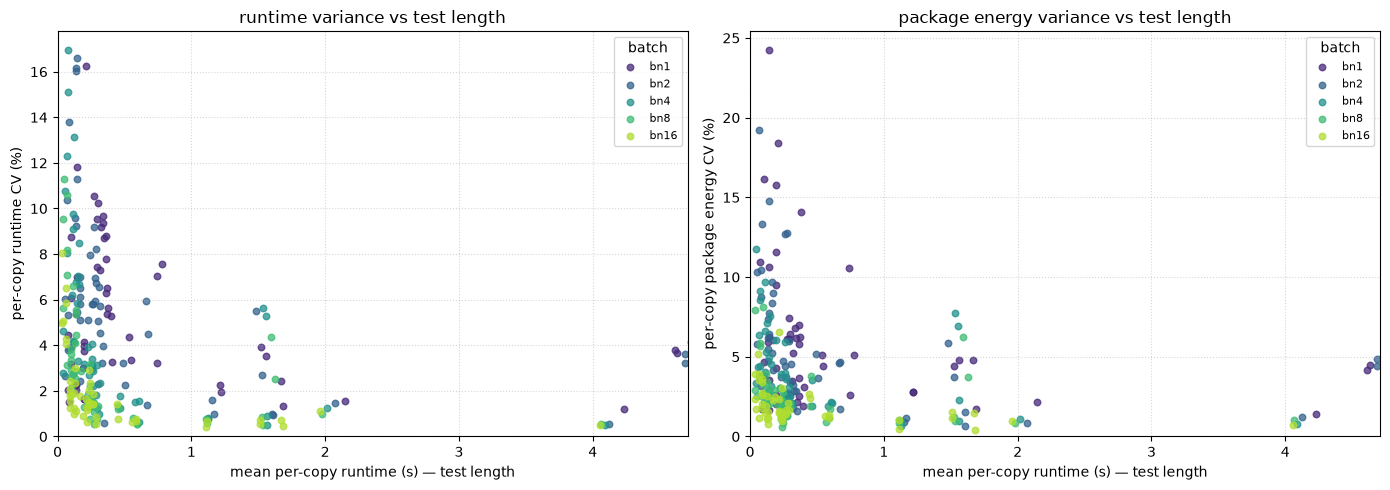

At batchnum=1, shortest third of queries: median runtime CV 3.5%; longest third: 3.5%.
Correlation with per-copy runtime (all points): runtime CV -0.30, energy CV -0.23


In [64]:
colB = plt.cm.viridis(np.linspace(0.12, 0.88, len(BATCH)))
size = var_t[["qid", "batchnum", "mean"]].rename(columns={"mean": "runtime_s"})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (v, title) in zip(axes, [(var_t, "runtime"), (var_e, "package energy")]):
    d = v.merge(size, on=["qid", "batchnum"])
    for j, b in enumerate(BATCH):
        s = d[d["batchnum"] == b]
        ax.scatter(s["runtime_s"], s["cv_pct"], s=22, color=colB[j], alpha=0.75,
                   label=f"bn{b}")
    ax.set_xlim(0, float(np.nanpercentile(d["runtime_s"], 96)))
    ax.set_ylim(bottom=0)
    ax.set_xlabel("mean per-copy runtime (s) — test length")
    ax.set_ylabel(f"per-copy {title} CV (%)")
    ax.set_title(f"{title} variance vs test length")
    ax.grid(linestyle=":", alpha=0.5); ax.legend(fontsize=8, title="batch")
fig.tight_layout(); plt.show()

# shortest vs longest tertiles at batchnum=1 (by runtime length)
b1 = var_t[var_t["batchnum"] == 1].dropna(subset=["mean", "cv_pct"])
q33, q67 = b1["mean"].quantile([1/3, 2/3])
short = b1[b1["mean"] <= q33]["cv_pct"].median()
long_ = b1[b1["mean"] >= q67]["cv_pct"].median()
print(f"At batchnum=1, shortest third of queries: median runtime CV {short:.1f}%; "
      f"longest third: {long_:.1f}%.")
ce = var_e.merge(size, on=["qid", "batchnum"])
print("Correlation with per-copy runtime (all points): "
      f"runtime CV {np.corrcoef(var_t['mean'].fillna(0), var_t['cv_pct'].fillna(0))[0,1]:+.2f}, "
      f"energy CV {np.corrcoef(ce['runtime_s'].fillna(0), ce['cv_pct'].fillna(0))[0,1]:+.2f}")


## 8. Variance vs `batchnum` — absolute spread

§3 showed the *relative* spread (CV%). This shows the **absolute** per-copy
standard deviation and how it collapses as the batch grows: the median per-copy
std across queries with the inter-quartile band and every query as a faint line.
Evenly-spaced batch ticks, linear y (clipped to the bulk so the median stays
readable). Units are seconds (runtime) and joules (energy) — the actual size of
the jitter you'd see on a single warm copy at each batch size.


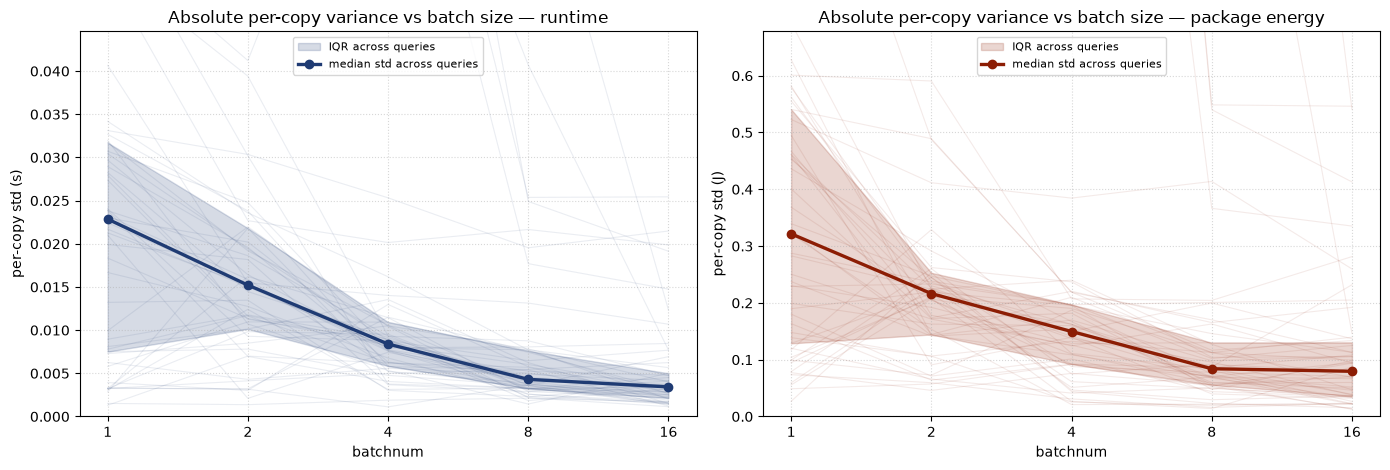

Median absolute per-copy std by batch size:
          runtime_std_s  energy_std_j
batchnum                             
1                0.0229        0.3216
2                0.0152        0.2164
4                0.0084        0.1496
8                0.0043        0.0841
16               0.0034        0.0796


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, (v, title, color, unit) in zip(
        axes, [(var_t, "runtime", "#1f3b73", "s"),
                (var_e, "package energy", "#8c1d04", "J")]):
    piv = v.pivot(index="qid", columns="batchnum", values="std").reindex(columns=BATCH)
    for _, row in piv.iterrows():
        ax.plot(xpos, row.values, color=color, alpha=0.09, lw=0.8)
    ax.fill_between(xpos, piv.quantile(0.25).values, piv.quantile(0.75).values,
                    color=color, alpha=0.18, label="IQR across queries")
    ax.plot(xpos, piv.median().values, color=color, marker="o", lw=2.4,
            label="median std across queries")
    ax.set_xticks(xpos); ax.set_xticklabels(BATCH)
    ax.set_ylim(0, float(np.nanpercentile(piv.values, 92)) * 1.15)
    ax.set_xlabel("batchnum")
    ax.set_ylabel(f"per-copy std ({unit})")
    ax.set_title(f"Absolute per-copy variance vs batch size — {title}")
    ax.grid(linestyle=":", alpha=0.5); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print("Median absolute per-copy std by batch size:")
tab = pd.DataFrame({
    "runtime_std_s": var_t.groupby("batchnum")["std"].median(),
    "energy_std_j": var_e.groupby("batchnum")["std"].median(),
}).round(4)
print(tab.to_string())


## 9. Does the variance come from test length (runtime) or from `batchnum`?

`batchnum` and runtime are the two things that vary here, and they are
confounded: a bigger batch simply takes longer, so "more variance at
`batchnum=16`" could just be "more variance because the run is 16× longer".
**Energy is an outcome, not a control**, so both the time-variance *and* the
energy-variance are explained against the same two candidates — **test length
(runtime)** and **`batchnum`** — and energy magnitude is never used as an x-axis.

Each point is one `(query, batchnum)`: the **mean whole-batch runtime** (test
length, x) against the **std of its repeats** (observed variance, y) — std of
**time** on the left, std of **energy** on the right, both against runtime.
Axes are log (values span ~4 orders), so the log-log slope is itself informative;
the grey lines on the runtime panel are constant-CV references.

The decisive number is the **partial correlation** printed below: the correlation
of the variance with `batchnum` *after removing test length*. If it is ≈ 0 (or
negative), `batchnum` adds nothing on its own — the variance rises only because
bigger batches run longer, and a bigger batch is if anything *relatively* quieter
because it averages more copies.


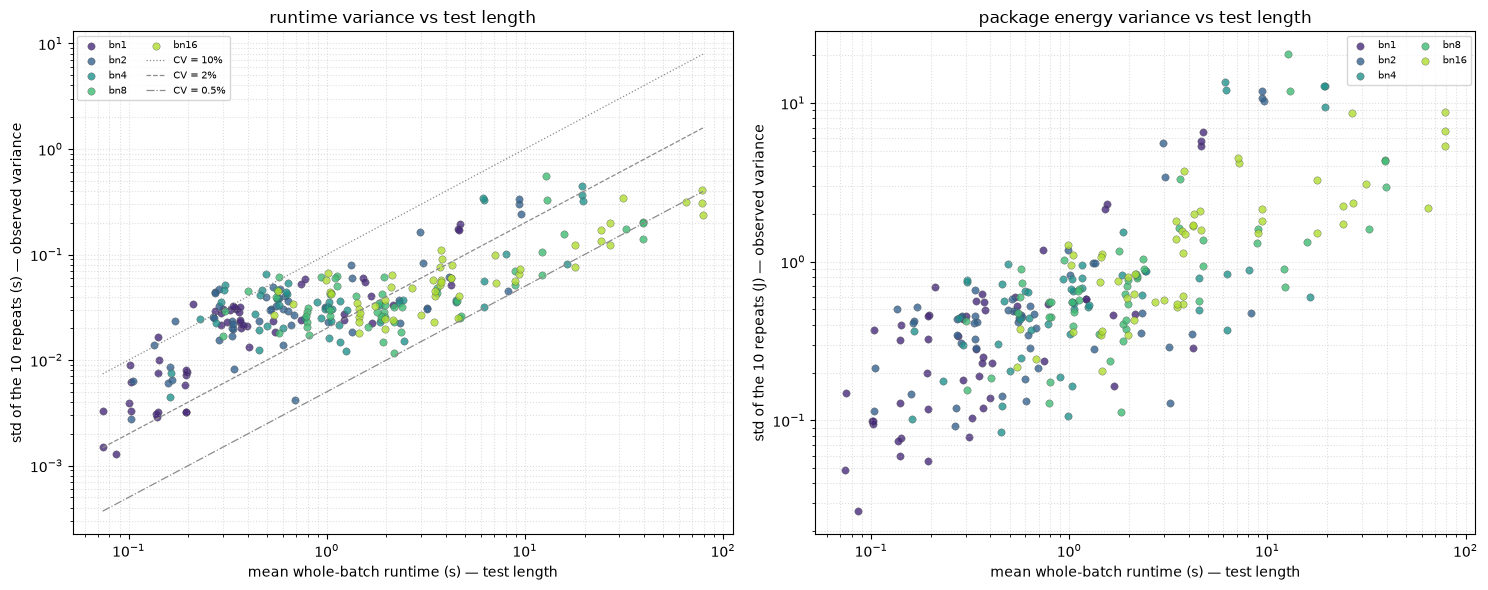

[runtime variance]  log-log slope vs test length = 0.54  (1.0 = variance proportional to run time)
          corr(variance, test length) = +0.79
          corr(variance, batchnum)    = +0.41
          PARTIAL corr(variance, batchnum | test length) = -0.10  <- batchnum's own effect once run time is held fixed
[energy variance]  log-log slope vs test length = 0.58  (1.0 = variance proportional to run time)
          corr(variance, test length) = +0.75
          corr(variance, batchnum)    = +0.39
          PARTIAL corr(variance, batchnum | test length) = -0.09  <- batchnum's own effect once run time is held fixed

Median CV(%) at each batchnum (relative spread of the outcome itself; falls as the batch averages more copies):
          runtime_cv%  energy_cv%
batchnum                         
1                4.16        4.77
2                5.31        4.62
4                3.10        2.90
8                1.69        2.09
16               1.41        1.53


In [66]:
mv = (measured.dropna(subset=["elapsed_sec"])
      .groupby(["qid", "batchnum"])
      .agg(mean_time=("elapsed_sec", "mean"), std_time=("elapsed_sec", "std"),
           mean_energy=("rapl_pkg_j", "mean"), std_energy=("rapl_pkg_j", "std"),
           n=("elapsed_sec", "count")).reset_index())
mv = mv[mv["n"] >= 2]
colB = plt.cm.viridis(np.linspace(0.12, 0.88, len(BATCH)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (ycol, title, unit) in zip(
        axes, [("std_time", "runtime", "s"),
               ("std_energy", "package energy", "J")]):
    for j, b in enumerate(BATCH):
        s = mv[mv["batchnum"] == b]
        ax.scatter(s["mean_time"], s[ycol], s=28, color=colB[j], alpha=0.8,
                   edgecolor="0.3", linewidth=0.3, label=f"bn{b}")
    if ycol == "std_time":                         # constant-CV guides (time only)
        xs = np.array([mv["mean_time"].min(), mv["mean_time"].max()])
        for cv, ls in [(10, ":"), (2, "--"), (0.5, "-.")]:
            ax.plot(xs, cv / 100 * xs, color="0.55", lw=0.9, ls=ls,
                    label=f"CV = {cv:g}%")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("mean whole-batch runtime (s) — test length")
    ax.set_ylabel(f"std of the {NREP} repeats ({unit}) — observed variance")
    ax.set_title(f"{title} variance vs test length")
    ax.grid(which="both", linestyle=":", alpha=0.4)
    ax.legend(fontsize=7, ncol=2)
fig.tight_layout(); plt.show()


def drivers(ycol, name):
    m = np.log10(mv["mean_time"].to_numpy())               # test length
    s = np.log10(mv[ycol].replace(0, np.nan).to_numpy())   # variance (outcome)
    b = np.log10(mv["batchnum"].to_numpy())
    ok = np.isfinite(m) & np.isfinite(s) & np.isfinite(b)
    m, s, b = m[ok], s[ok], b[ok]
    slope = np.polyfit(m, s, 1)[0]

    def resid(y, x):
        a, c = np.polyfit(x, y, 1)
        return y - (a * x + c)
    pc = np.corrcoef(resid(s, m), resid(b, m))[0, 1]
    print(f"[{name} variance]  log-log slope vs test length = {slope:.2f}  "
          f"(1.0 = variance proportional to run time)")
    print(f"          corr(variance, test length) = {np.corrcoef(m, s)[0,1]:+.2f}")
    print(f"          corr(variance, batchnum)    = {np.corrcoef(b, s)[0,1]:+.2f}")
    print(f"          PARTIAL corr(variance, batchnum | test length) = {pc:+.2f}  "
          f"<- batchnum's own effect once run time is held fixed")


drivers("std_time", "runtime")
drivers("std_energy", "energy")
print("\nMedian CV(%) at each batchnum (relative spread of the outcome itself; "
      "falls as the batch averages more copies):")
mv["cv_time"] = 100 * mv["std_time"] / mv["mean_time"]
mv["cv_energy"] = 100 * mv["std_energy"] / mv["mean_energy"]
print(pd.DataFrame({
    "runtime_cv%": mv.groupby("batchnum")["cv_time"].median(),
    "energy_cv%": mv.groupby("batchnum")["cv_energy"].median(),
}).round(2).to_string())


## 10. How many tests are needed? Repeats × batch-set sensitivity

The 530-group run is deliberately over-sampled (10 repeats, 5 batch sizes). This
section asks **how much of it you actually need** to recover the two fit
parameters — the **energy slope** (the per-run energy cost, the headline number)
and, secondarily, the **overhead** — plus the runtime slope as a cross-check.

Method: the **full design** (all repeats × all 5 batch sizes) is taken as ground
truth. For every candidate design — `R` repeats × a subset of the batch sizes —
we refit each query's line and measure the **relative error of its slope vs the
full-design slope**, then take the **median across queries**. To remove "which
repeats you happened to pick" from the answer, each cell is averaged **exactly
over all `C(10,R)` ways** of choosing the `R` repeats (no random sampling).
Because every choice is enumerated, we also report the **standard deviation
across those `C(10,R)` choices** — how much the accuracy depends on *which*
repeats you happen to use (it shrinks as `R` grows, and is exactly 0 at `R=10`
where only one choice exists).

There is **one heatmap per metric** (energy slope, energy overhead, runtime
slope), all on the **same colour scale** so they are directly comparable, and
each saved as an **SVG in `./figures/`**. Every cell shows three lines: the
accuracy `mean ± std` (%, two decimals); the **per-query run count**
(`runs/q` — executions for one query, warm-ups included); and the **estimated
per-query wall time** (`~t/q` — the run's `summary.txt` average seconds per full
group, scaled by repeats and by the batch set's copy count). Both costs are
**per single query**: the query count can change run-to-run, but the per-query
cost is the stable planning number.

The tables/heatmaps have **rows = batch set** and **columns = number of
repeats**, so the top row (all 5 batches) answers "how many repeats?" and the
last column (all 10 repeats) answers "how few batch sizes?". Overhead is reported
as a % of **one run's cost** (its natural scale — it is often near zero, so a
plain relative error would explode).


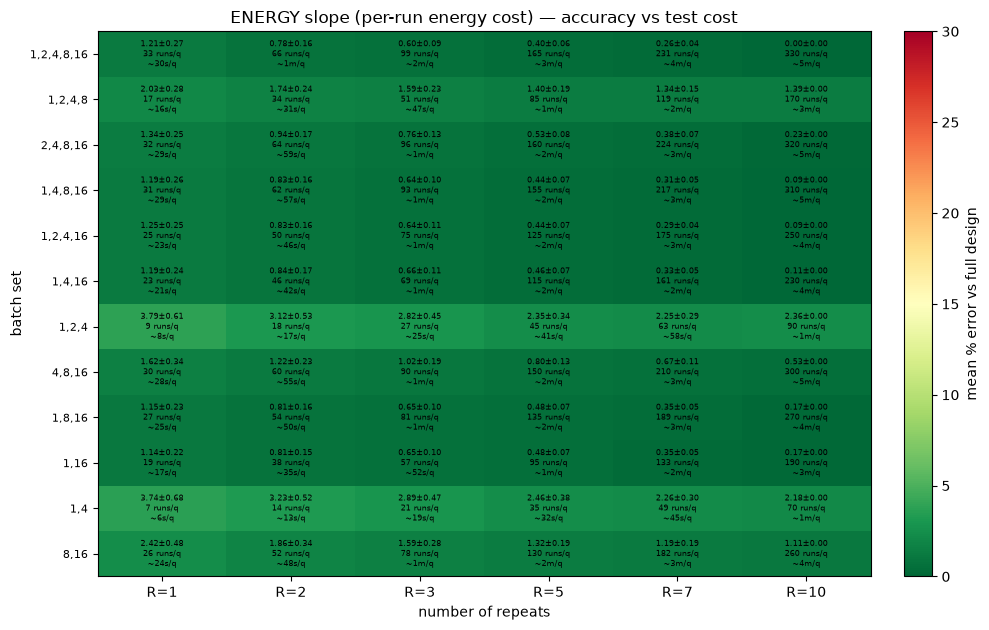

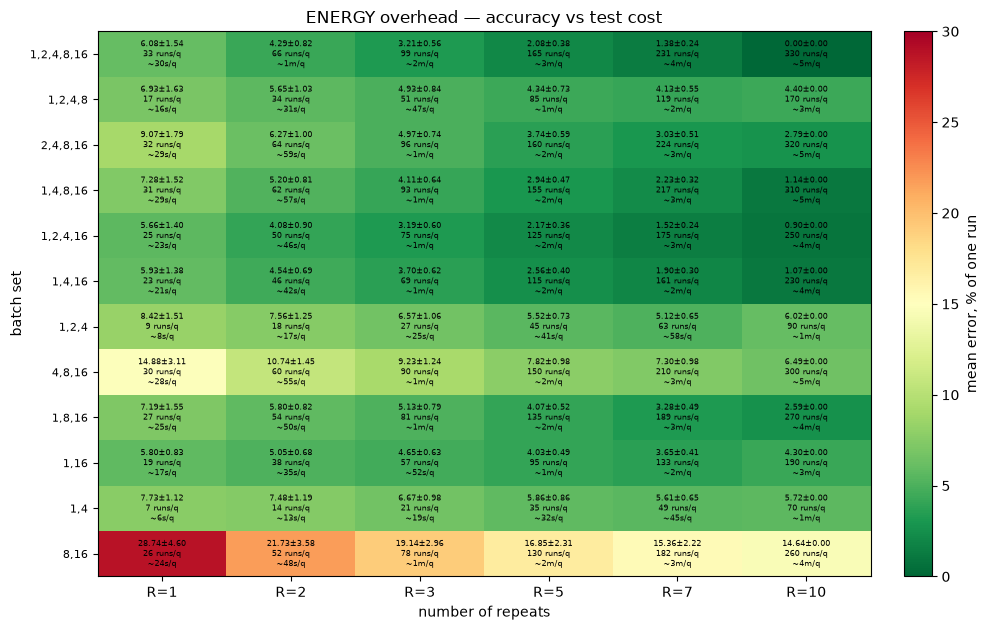

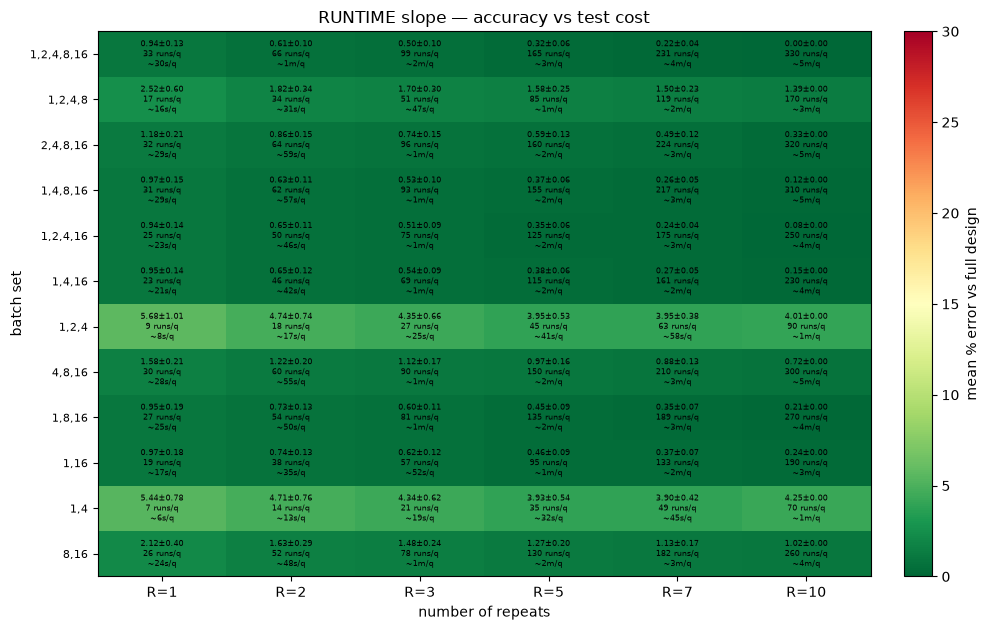

Saved 3 SVGs to 'figures/' (shared colour scale 0-30).
Ground truth = full design (10 repeats x 5 batch sizes).
Queries with a complete cube: energy 53/53, runtime 53/53.
Cost model: 2 warm-ups + batch copies per group; 30.4s per full group (from summary.txt). 'runs/q' and '~t/q' are per SINGLE query (this run has 53); per-query cost is the query-count-agnostic planning number.

Each cell below is the MEAN over all C(10,R) repeat choices; the matching
std table is the spread ACROSS those choices (how much it depends on WHICH
repeats you pick — it shrinks as R grows and is 0 at R=10, the only choice).

=== ENERGY slope — mean relative error vs full design (%) ===
             R=1   R=2   R=3   R=5   R=7  R=10
1,2,4,8,16  1.21  0.78  0.60  0.40  0.26  0.00
1,2,4,8     2.03  1.74  1.59  1.40  1.34  1.39
2,4,8,16    1.34  0.94  0.76  0.53  0.38  0.23
1,4,8,16    1.19  0.83  0.64  0.44  0.31  0.09
1,2,4,16    1.25  0.83  0.64  0.44  0.29  0.09
1,4,16      1.19  0.84  0.66  0.46  0.33  0.11


In [67]:
import itertools

QIDS = sorted(measured["qid"].unique())
qpos = {q: i for i, q in enumerate(QIDS)}
bpos = {b: i for i, b in enumerate(BATCH)}
R_AVAIL = int(measured["repeat"].max())


def build_cube(col):
    C = np.full((len(QIDS), len(BATCH), R_AVAIL), np.nan)
    sub = measured.dropna(subset=[col])
    for q, b, r, v in zip(sub["qid"], sub["batchnum"], sub["repeat"], sub[col]):
        C[qpos[q], bpos[int(b)], int(r) - 1] = v
    return C


cube_E = build_cube("rapl_pkg_j")
cube_T = build_cube("elapsed_sec")


def slopes_intercepts(C, qmask, b_idx, r_idx):
    sub = C[qmask][:, b_idx][:, :, r_idx]              # (Qk, nb, nr)
    Y = sub.reshape(sub.shape[0], -1)
    x = np.repeat(np.array([BATCH[i] for i in b_idx], float), len(r_idx))
    xbar = x.mean(); xc = x - xbar; Sxx = (xc ** 2).sum()
    slope = Y @ xc / Sxx                               # OLS, vectorised over queries
    intercept = Y.mean(axis=1) - slope * xbar
    return slope, intercept


# candidate batch sets (each >= 2 distinct sizes), restricted to what this run has
BATCH_SETS = [[1, 2, 4, 8, 16], [1, 2, 4, 8], [2, 4, 8, 16], [1, 4, 8, 16],
              [1, 2, 4, 16], [1, 4, 16], [1, 2, 4], [4, 8, 16], [1, 8, 16],
              [1, 16], [1, 4], [8, 16]]
BATCH_SETS = [bs for bs in BATCH_SETS if set(bs) <= set(BATCH)]
R_LIST = [r for r in [1, 2, 3, 5, 7, 10] if r <= R_AVAIL]


def sensitivity(C, kind):
    qmask = ~np.isnan(C).any(axis=(1, 2))             # queries with a complete cube
    s_true, o_true = slopes_intercepts(
        C, qmask, list(range(len(BATCH))), list(range(R_AVAIL)))
    denom = np.abs(s_true)                            # per-run cost = natural scale
    idx = [",".join(map(str, bs)) for bs in BATCH_SETS]
    cols = [f"R={r}" for r in R_LIST]
    mean_tab = pd.DataFrame(index=idx, columns=cols, dtype=float)
    std_tab = pd.DataFrame(index=idx, columns=cols, dtype=float)
    for bs in BATCH_SETS:
        b_idx = [bpos[b] for b in bs]
        for R in R_LIST:
            errs = []
            for r_combo in itertools.combinations(range(R_AVAIL), R):
                s_est, o_est = slopes_intercepts(C, qmask, b_idx, list(r_combo))
                est, true = (s_est, s_true) if kind == "slope" else (o_est, o_true)
                errs.append(np.median(np.abs(est - true) / denom))
            errs = 100 * np.array(errs)              # one median-error per repeat-combo
            lbl = ",".join(map(str, bs))
            mean_tab.loc[lbl, f"R={R}"] = errs.mean()
            # std ACROSS the C(R_AVAIL, R) repeat choices (0 when only one combo)
            std_tab.loc[lbl, f"R={R}"] = errs.std(ddof=1) if len(errs) > 1 else 0.0
    return mean_tab, std_tab, int(qmask.sum())


tab_Es, std_Es, nE = sensitivity(cube_E, "slope")
tab_Eo, std_Eo, _ = sensitivity(cube_E, "overhead")
tab_Ts, std_Ts, nT = sensitivity(cube_T, "slope")


# ---- design cost: total run count and estimated per-query wall time ----
WARMUPS = int(round(warm.groupby(["qid", "repeat"]).size().mean()))   # ~2 per group
NQ = len(QIDS)
full_copies = WARMUPS + sum(BATCH)


def _sec_per_entry():
    d = SEL["timing_key"].rsplit("/", 1)[0] if "/" in SEL["timing_key"] else ""
    skey = (d + "/summary.txt") if d else "summary.txt"
    if skey in BLOBS:
        t = BLOBS[skey].decode("utf-8", "replace")
        sec = re.search(r"\((\d+)\s*seconds\)", t)
        ent = re.search(r"entries:\s*(\d+)", t)
        if sec and ent:
            return int(sec.group(1)) / int(ent.group(1)), "summary.txt"
    # fallback: mean wall time per group from the timing rows themselves
    return raw["elapsed_sec"].sum() / raw["run_id"].nunique(), "data estimate"


SEC_PER_ENTRY, SEC_SRC = _sec_per_entry()


def _copies(bs):
    return WARMUPS + sum(bs)


def cost_grid(fn):
    return pd.DataFrame(
        {f"R={R}": [fn(bs, R) for bs in BATCH_SETS] for R in R_LIST},
        index=[",".join(map(str, bs)) for bs in BATCH_SETS])


RUNS = cost_grid(lambda bs, R: R * _copies(bs))     # per SINGLE query (query-count-agnostic)
SECS = cost_grid(lambda bs, R: R * SEC_PER_ENTRY * _copies(bs) / full_copies)


def fmt_dur(s):
    if s >= 3600:
        return f"{s / 3600:.1f}h"
    if s >= 60:
        return f"{s / 60:.0f}m"
    return f"{s:.0f}s"


FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
# shared colour limits so all three heatmaps are directly comparable
VMAX = float(np.ceil(max(np.nanmax(tab_Es.to_numpy()), np.nanmax(tab_Eo.to_numpy()),
                         np.nanmax(tab_Ts.to_numpy())) / 5.0) * 5)


def heat(tab, std, title, cbar_label, fname):
    A = tab.to_numpy(dtype=float); S = std.to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(10, 6.4))
    im = ax.imshow(A, cmap="RdYlGn_r", vmin=0, vmax=VMAX, aspect="auto")
    ax.set_xticks(range(tab.shape[1])); ax.set_xticklabels(tab.columns)
    ax.set_yticks(range(tab.shape[0])); ax.set_yticklabels(tab.index, fontsize=8)
    for i, bs in enumerate(tab.index):
        for j, col in enumerate(tab.columns):
            ax.text(j, i, f"{A[i, j]:.2f}±{S[i, j]:.2f}\n"
                          f"{int(RUNS.loc[bs, col])} runs/q\n"
                          f"~{fmt_dur(SECS.loc[bs, col])}/q",
                    ha="center", va="center", fontsize=6.0)
    ax.set_xlabel("number of repeats"); ax.set_ylabel("batch set")
    ax.set_title(title)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(cbar_label)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, format="svg", bbox_inches="tight")
    plt.show()


heat(tab_Es, std_Es, "ENERGY slope (per-run energy cost) — accuracy vs test cost",
     "mean % error vs full design", "repeats_x_batch_energy_slope.svg")
heat(tab_Eo, std_Eo, "ENERGY overhead — accuracy vs test cost",
     "mean error, % of one run", "repeats_x_batch_energy_overhead.svg")
heat(tab_Ts, std_Ts, "RUNTIME slope — accuracy vs test cost",
     "mean % error vs full design", "repeats_x_batch_runtime_slope.svg")
print(f"Saved 3 SVGs to '{FIG_DIR}/' (shared colour scale 0-{VMAX:g}).")

print(f"Ground truth = full design ({R_AVAIL} repeats x {len(BATCH)} batch sizes).")
print(f"Queries with a complete cube: energy {nE}/{len(QIDS)}, "
      f"runtime {nT}/{len(QIDS)}.")
print(f"Cost model: {WARMUPS} warm-ups + batch copies per group; "
      f"{SEC_PER_ENTRY:.1f}s per full group (from {SEC_SRC}). "
      f"'runs/q' and '~t/q' are per SINGLE query (this run has {NQ}); "
      f"per-query cost is the query-count-agnostic planning number.\n")
print("Each cell below is the MEAN over all C(10,R) repeat choices; the matching")
print("std table is the spread ACROSS those choices (how much it depends on WHICH")
print("repeats you pick — it shrinks as R grows and is 0 at R=10, the only choice).")
print("\n=== ENERGY slope — mean relative error vs full design (%) ===")
print(tab_Es.round(2).to_string())
print("--- ENERGY slope — std across repeat choices (%) ---")
print(std_Es.round(2).to_string())
print("\n=== ENERGY overhead — mean error as % of one run's energy ===")
print(tab_Eo.round(2).to_string())
print("--- ENERGY overhead — std across repeat choices (%) ---")
print(std_Eo.round(2).to_string())
print("\n=== RUNTIME slope — mean relative error vs full design (%) ===")
print(tab_Ts.round(2).to_string())
print("--- RUNTIME slope — std across repeat choices (%) ---")
print(std_Ts.round(2).to_string())

full = "1,2,4,8,16"
print("\n-- how many repeats? (all 5 batch sizes) --")
for R in R_LIST:
    print(f"   R={R:<2}: energy slope {tab_Es.loc[full, f'R={R}']:.1f}% error")
print("-- how few batch sizes? (all repeats) --")
lastcol = f"R={R_AVAIL}"
for bs in tab_Es.index:
    print(f"   {bs:<12}: energy slope {tab_Es.loc[bs, lastcol]:.1f}% error")


## 11. Cheapest configuration per accuracy cutoff

The planning view: for a series of **accuracy cutoffs** on the
**energy-slope error** (error ≤ 0.2%, ≤ 0.4%, ≤ 0.6%, …), list the
configurations that meet the tolerance with the **fewest runs per query**
(top 3), rendered as a **table figure for cutoffs up to 2%**. Cutoffs are
cumulative — a looser tolerance admits everything a tighter
one did, plus cheaper (higher-error) configs — so the cheapest qualifying design
gets cheaper as you relax the cutoff. Each line shows the config, its
`error ± std`, the per-query run count and estimated wall time.

A `*Pareto` tag marks configs on the global accuracy-vs-cost frontier — nothing
else is both cheaper **and** at least as accurate, so those are the only ones
actually worth choosing. The cheapest config meeting each cutoff is **always** one
of them (sorting by runs then error makes row 1 provably Pareto-optimal), so the
tolerance's best pick is always shown; a guard would append it if the top-N ever
missed it (the printed count of such appends is 0 here). The scatter draws that
frontier through all configs; it
*is* the "least runs to reach a given accuracy" curve. Swap `tab_Es` for
`tab_Ts` / `tab_Eo` to use runtime-slope or overhead instead.


Pareto-guarantee check: cutoffs whose top-3 lacked a Pareto config (extra rows appended): 0


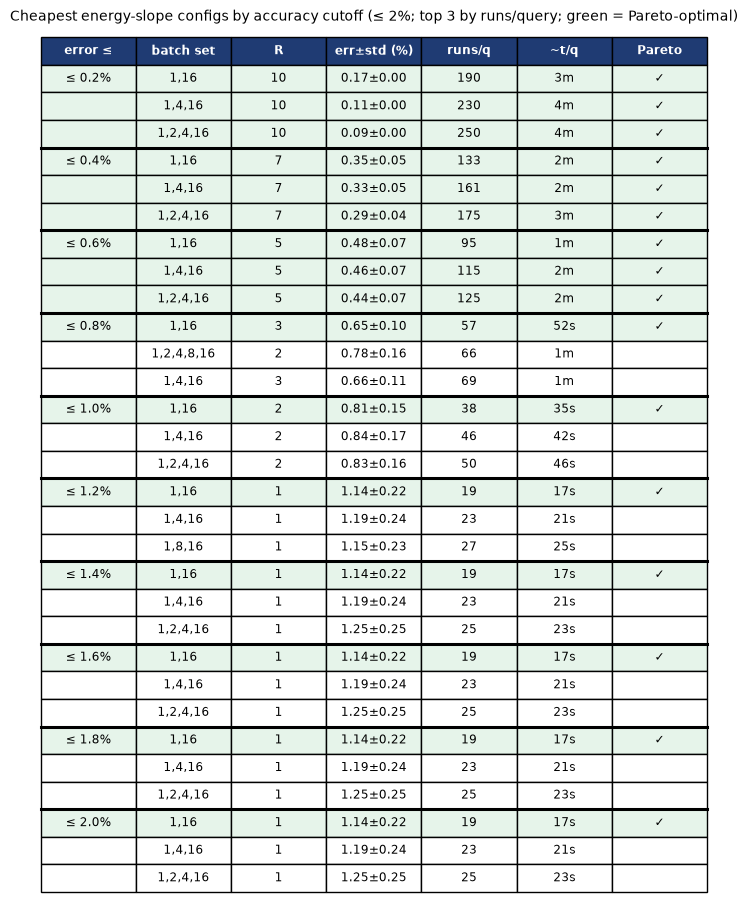



Pareto frontier — the least runs to reach each accuracy level:
   1,4         R=1  err 3.74±0.68%     7 runs/q   ~6s/q
   1,4         R=2  err 3.23±0.52%    14 runs/q   ~13s/q
   1,2,4,8     R=1  err 2.03±0.28%    17 runs/q   ~16s/q
   1,16        R=1  err 1.14±0.22%    19 runs/q   ~17s/q
   1,16        R=2  err 0.81±0.15%    38 runs/q   ~35s/q
   1,16        R=3  err 0.65±0.10%    57 runs/q   ~52s/q
   1,2,4,16    R=3  err 0.64±0.11%    75 runs/q   ~1m/q
   1,16        R=5  err 0.48±0.07%    95 runs/q   ~1m/q
   1,4,16      R=5  err 0.46±0.07%   115 runs/q   ~2m/q
   1,2,4,16    R=5  err 0.44±0.07%   125 runs/q   ~2m/q
   1,16        R=7  err 0.35±0.05%   133 runs/q   ~2m/q
   1,4,16      R=7  err 0.33±0.05%   161 runs/q   ~2m/q
   1,2,4,16    R=7  err 0.29±0.04%   175 runs/q   ~3m/q
   1,16        R=10 err 0.17±0.00%   190 runs/q   ~3m/q
   1,4,16      R=10 err 0.11±0.00%   230 runs/q   ~4m/q
   1,2,4,16    R=10 err 0.09±0.00%   250 runs/q   ~4m/q
   1,4,8,16    R=10 err 0.09±0.00%

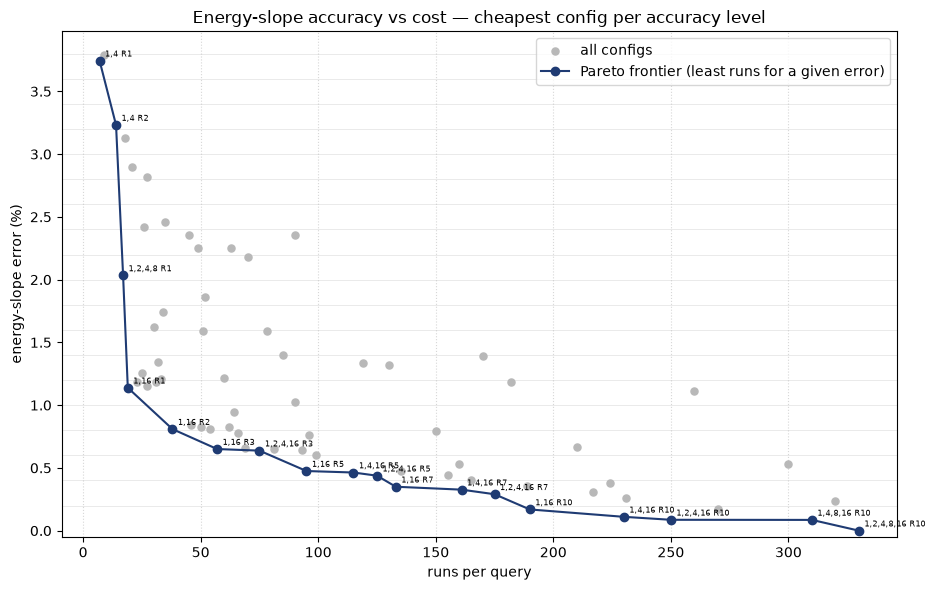

In [68]:
STEP = 0.2         # spacing of the accuracy cutoffs, in % error


def config_table(mean_tab, std_tab):
    recs = []
    for bs in mean_tab.index:
        for col in mean_tab.columns:
            recs.append(dict(batch_set=bs, R=int(col.split("=")[1]),
                             err=float(mean_tab.loc[bs, col]),
                             std=float(std_tab.loc[bs, col]),
                             runs=int(RUNS.loc[bs, col]),
                             secs=float(SECS.loc[bs, col])))
    df = pd.DataFrame(recs)
    # Pareto-optimal = no other config is <= on BOTH err and runs (and < on one)
    e, r = df["err"].to_numpy(), df["runs"].to_numpy()
    dominated = (((e[None, :] <= e[:, None]) & (r[None, :] <= r[:, None]) &
                  ((e[None, :] < e[:, None]) | (r[None, :] < r[:, None]))).any(axis=1))
    df["pareto"] = ~dominated
    return df


cfg = config_table(tab_Es, std_Es)

# ---- figure table: cheapest configs per accuracy cutoff (up to 2%) ----
MAX_CUT = 2.0
TOPN_TAB = 3
cols = ["error ≤", "batch set", "R", "err±std (%)",
        "runs/q", "~t/q", "Pareto"]
rows, rowcolors, n_extra = [], [], 0
for c in np.arange(STEP, MAX_CUT + 1e-9, STEP):
    feas = cfg[cfg["err"] <= c + 1e-9].sort_values(["runs", "err"])
    shown = feas.head(TOPN_TAB)
    # guarantee each cutoff shows its Pareto-optimal (best non-dominated) pick:
    # sorting by (runs, err) makes row 1 always Pareto, so this never triggers,
    # but if a top-N ever lacked one we append the cheapest Pareto config here.
    if not shown["pareto"].any() and feas["pareto"].any():
        shown = pd.concat([shown, feas[feas["pareto"]].head(1)])
        n_extra += 1
    for k, (_, x) in enumerate(shown.iterrows()):
        rows.append([f"≤ {c:.1f}%" if k == 0 else "", x["batch_set"],
                     str(int(x["R"])), f"{x['err']:.2f}±{x['std']:.2f}",
                     str(int(x["runs"])), fmt_dur(x["secs"]),
                     "✓" if x["pareto"] else ""])
        rowcolors.append("#e6f4ea" if x["pareto"] else "white")   # green = Pareto
group_starts = [i for i, r in enumerate(rows) if r[0]]            # first row per cutoff
print(f"Pareto-guarantee check: cutoffs whose top-{TOPN_TAB} lacked a Pareto "
      f"config (extra rows appended): {n_extra}")

n_total = len(rows) + 1
fig, ax = plt.subplots(figsize=(8.6, 0.34 * len(rows) + 0.9))
ax.axis("off")
tbl = ax.table(cellText=rows, colLabels=cols, cellLoc="center", bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
for j in range(len(cols)):
    tbl[0, j].set_facecolor("#1f3b73")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for i, rc in enumerate(rowcolors):
    for j in range(len(cols)):
        tbl[i + 1, j].set_facecolor(rc)
# bold separator line between each accuracy-cutoff section
for g in group_starts[1:]:
    y = 1 - (g + 1) / n_total
    ax.plot([0, 1], [y, y], transform=ax.transAxes, color="black", lw=2.2,
            clip_on=False, zorder=5)
ax.set_title(f"Cheapest energy-slope configs by accuracy cutoff "
             f"(≤ {MAX_CUT:g}%; top {TOPN_TAB} by runs/query; "
             "green = Pareto-optimal)", fontsize=10, pad=12)
fig.savefig(FIG_DIR / "accuracy_cutoffs_table_energy_slope.svg",
            format="svg", bbox_inches="tight")
plt.show()

cuts = np.arange(STEP, np.ceil(cfg["err"].max() / STEP) * STEP + STEP, STEP)

print("\n\nPareto frontier — the least runs to reach each accuracy level:")
pf = cfg[cfg["pareto"]].sort_values("runs")
for _, x in pf.iterrows():
    print(f"   {x['batch_set']:<11} R={int(x['R']):<2} "
          f"err {x['err']:.2f}±{x['std']:.2f}%   "
          f"{int(x['runs']):>3} runs/q   ~{fmt_dur(x['secs'])}/q")

# ---- scatter: every config, with the accuracy-vs-cost frontier ----
fig, ax = plt.subplots(figsize=(9.5, 6))
ax.scatter(cfg["runs"], cfg["err"], s=26, color="0.72", zorder=2,
           label="all configs")
ax.plot(pf["runs"], pf["err"], "-o", color="#1f3b73", zorder=3,
        label="Pareto frontier (least runs for a given error)")
for _, x in pf.iterrows():
    ax.annotate(f"{x['batch_set']} R{int(x['R'])}", (x["runs"], x["err"]),
                fontsize=6, xytext=(4, 3), textcoords="offset points")
for e in cuts:
    ax.axhline(e, color="0.9", lw=0.6, zorder=0)
ax.set_xlabel("runs per query"); ax.set_ylabel("energy-slope error (%)")
ax.set_ylim(bottom=-0.05)
ax.set_title("Energy-slope accuracy vs cost — cheapest config per accuracy level")
ax.grid(axis="x", linestyle=":", alpha=0.5); ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "accuracy_buckets_energy_slope.svg",
            format="svg", bbox_inches="tight")
plt.show()


## 12. Uneven repeat allocation across batch sizes

§10–§11 used the same repeat count `R` at every batch size. But a repeat at
batchnum 16 costs ~16× one at batchnum 1 while being only ~4× noisier
(`σ ∝ √magnitude`, §9), so in principle repeats can be spent **unevenly** — more
where measurement is cheap, fewer where it is expensive. For a two-point design
the optimal split minimises the slope's sampling variance at fixed cost
`Σ nₓcₓ`, giving (with the per-batchnum leverage) `nₓ ∝ |x−x̄|·σₓ/√cₓ`.

Enumerating every allocation *empirically* is intractable, so we **predict** each
one: per query, its error is `√(bias² + Var(b̂))`, where **bias** is the batch
set's own error at full repeats (the floor from dropping batch sizes, from §10's
`R=10` column) and **Var(b̂)** is the slope's variance from sub-sampling the
repeats — `Var = Σ (x−x̄)²σₓ²(1/nₓ − 1/N) / [Σ(x−x̄)²]²`, a fit-the-means slope
with a **finite-population correction** (the `N=10` repeats *are* the
population), and the noise term scaled by `0.674` (median/σ) so the RMS matches
§11's *median* metric. The correction makes the prediction reduce to the pure
bias at full repeats; the check below confirms it reproduces §11's `{1,16}` row
across all repeat counts. We report the **median relative error across queries**.

Below: (a) the suggested allocation shape per batch set and a check that the
model reproduces §11 for uniform allocation; then (b) a cutoff table over
allocations. Batch sets whose **full-data error already exceeds 1%** are dropped
(no allocation beats the bias floor), the **max cutoff is 1%**, and we show the
top **20** configs at ≤0.2%, **10** at ≤0.4%, and **3** for the rest. Cost is
`runs/q = 2·max(nₓ) + Σ nₓ·x` (warm-ups shared per restart group, matching §11).


In [69]:
# per-query, per-batchnum mean and std of whole-batch ENERGY, from §10's cube
xall = np.array(BATCH, float)
N_REP = R_AVAIL                         # the repeats ARE the finite population
qmE = ~np.isnan(cube_E).any(axis=(1, 2))
CE = cube_E[qmE]
meanx = CE.mean(axis=2)                 # (Qk, 5) mean over the repeats
sdx = CE.std(axis=2, ddof=1)           # (Qk, 5) std over the repeats


def _slope(Y, xs):                      # fit-the-means slope (one point per batchnum)
    xc = xs - xs.mean()
    return (Y * xc).sum(1) / (xc ** 2).sum()


b_full = _slope(meanx, xall)            # full-design slope per query = ground truth
ab = np.abs(b_full)

# batch sets worth keeping: full-data (R=10) error <= 1%
kept = [bs for bs in BATCH_SETS
        if tab_Es.loc[",".join(map(str, bs)), "R=10"] <= 1.0]


MED = 0.6745    # median(|N(0,σ)|)/σ — calibrates the RMS noise term to §11's median


def alloc_error(idx, n, bias):
    """predicted median % slope error for allocation n over batch indices idx."""
    xs = xall[idx]; lev = (xs - xs.mean()) ** 2; DB = lev.sum()
    inv = 1.0 / np.asarray(n, float) - 1.0 / N_REP        # finite-pop correction
    Var = (lev * sdx[:, idx] ** 2 * inv).sum(1) / DB ** 2  # (Qk,)
    return 100 * np.median(np.sqrt(bias ** 2 + (MED ** 2) * Var) / ab)


print("Suggested allocation shape  (nₓ ∝ |x−x̄|·σₓ/√cₓ, cₓ = 2+x; min = 1):")
for bs in kept:
    idx = [bpos[b] for b in bs]; xs = xall[idx]
    sg = np.median(sdx[:, idx], axis=0)
    w = np.abs(xs - xs.mean()) * sg / np.sqrt([2 + b for b in bs])
    w = w / w[w > 0].min()
    print(f"  {','.join(map(str, bs)):<12} -> "
          + ",  ".join(f"bn{b}:{wi:.1f}" for b, wi in zip(bs, w)))

print("\nModel check — predicted vs §11 empirical error for uniform {1,16}:")
idx16 = [bpos[1], bpos[16]]
bias16 = _slope(meanx[:, idx16], xall[idx16]) - b_full
for R in [1, 2, 3, 5, 10]:
    print(f"   R={R:<2} predicted {alloc_error(idx16, [R, R], bias16):.2f}%   "
          f"§11 empirical {tab_Es.loc['1,16', f'R={R}']:.2f}%")


Suggested allocation shape  (nₓ ∝ |x−x̄|·σₓ/√cₓ, cₓ = 2+x; min = 1):
  1,2,4,8,16   -> bn1:2.5,  bn2:2.4,  bn4:1.4,  bn8:1.0,  bn16:7.7
  2,4,8,16     -> bn2:11.2,  bn4:8.0,  bn8:1.0,  bn16:24.0
  1,4,8,16     -> bn1:7.3,  bn4:5.0,  bn8:1.0,  bn16:16.5
  1,2,4,16     -> bn1:2.1,  bn2:1.9,  bn4:1.0,  bn16:7.2
  1,4,16       -> bn1:1.5,  bn4:1.0,  bn16:3.7
  4,8,16       -> bn4:4.6,  bn8:1.0,  bn16:7.1
  1,8,16       -> bn1:19.2,  bn8:1.0,  bn16:32.4
  1,16         -> bn1:1.0,  bn16:1.6

Model check — predicted vs §11 empirical error for uniform {1,16}:
   R=1  predicted 1.17%   §11 empirical 1.14%
   R=2  predicted 0.86%   §11 empirical 0.81%
   R=3  predicted 0.73%   §11 empirical 0.65%
   R=5  predicted 0.50%   §11 empirical 0.48%
   R=10 predicted 0.17%   §11 empirical 0.17%


5400 allocations over 8 batch sets; 94 on the Pareto frontier.


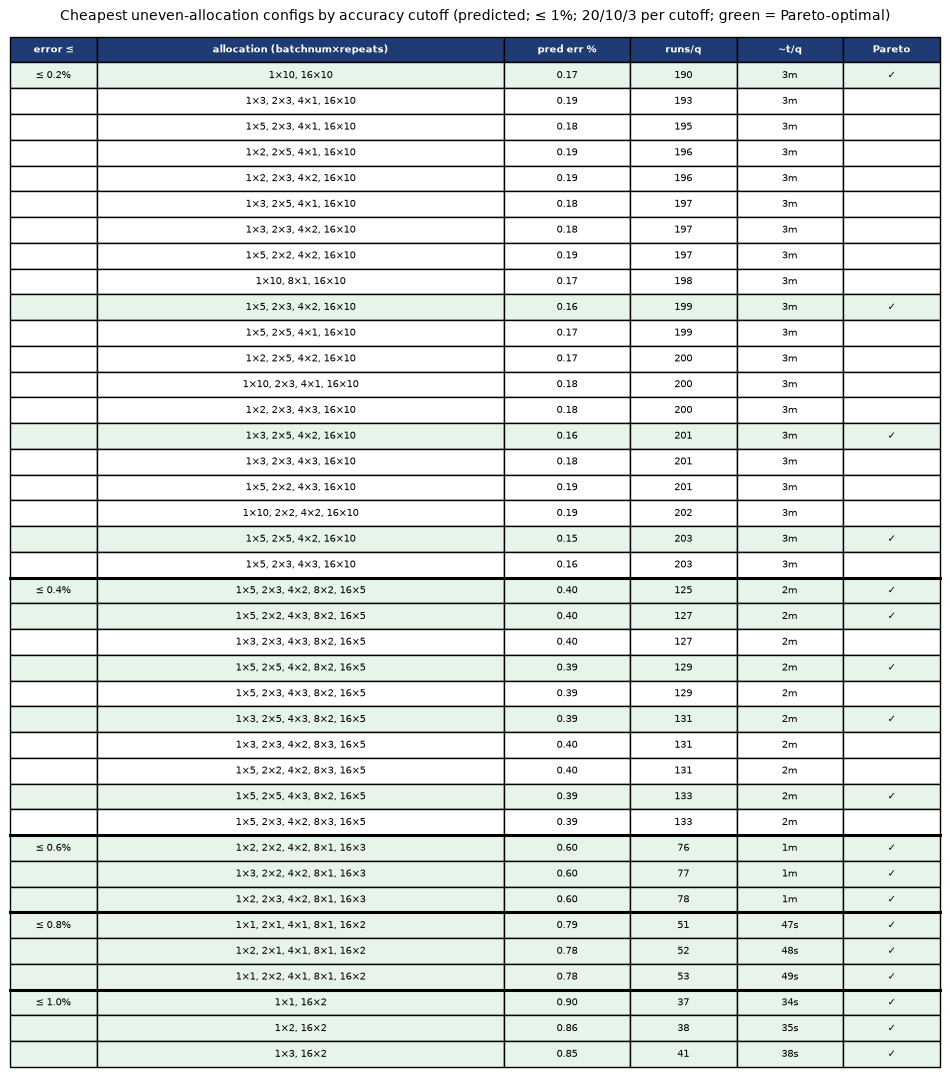

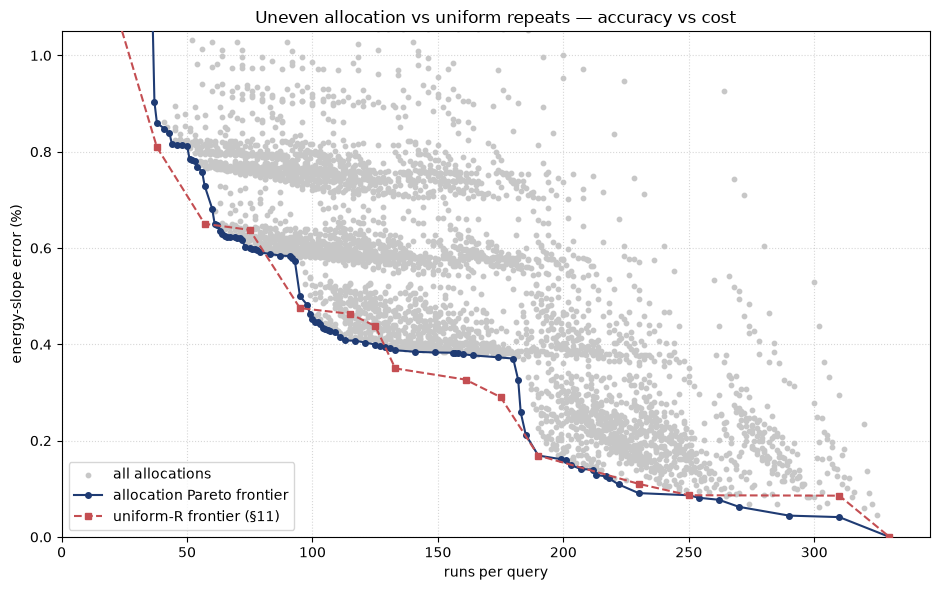

In [70]:
# ---- enumerate per-batchnum allocations and predict accuracy + cost ----
ALLOC_R = [1, 2, 3, 5, 10]                       # repeats allowed at each batchnum
recs = []
for bs in kept:
    idx = [bpos[b] for b in bs]
    bias = _slope(meanx[:, idx], xall[idx]) - b_full
    for n in itertools.product(ALLOC_R, repeat=len(idx)):
        err = alloc_error(idx, n, bias)
        runs = int(2 * max(n) + sum(ni * x for ni, x in zip(n, bs)))
        recs.append((", ".join(f"{x}×{ni}" for x, ni in zip(bs, n)),
                     err, runs, SEC_PER_ENTRY * runs / full_copies))
cfg2 = pd.DataFrame(recs, columns=["alloc", "err", "runs", "secs"])

# Pareto frontier (min err, min runs) via a cheap runs-sorted sweep
cfg2 = cfg2.sort_values(["runs", "err"]).reset_index(drop=True)
best = np.inf; par = np.zeros(len(cfg2), bool)
for i in range(len(cfg2)):
    if cfg2.at[i, "err"] < best - 1e-12:
        par[i] = True; best = cfg2.at[i, "err"]
cfg2["pareto"] = par
print(f"{len(cfg2)} allocations over {len(kept)} batch sets; "
      f"{int(par.sum())} on the Pareto frontier.")

# ---- cutoff table figure (max 1%; 20 / 10 / 3 rows) ----
PERCUT = {0.2: 20, 0.4: 10}
cols = ["error ≤", "allocation (batchnum×repeats)", "pred err %",
        "runs/q", "~t/q", "Pareto"]
rows, rowcolors = [], []
for c in [0.2, 0.4, 0.6, 0.8, 1.0]:
    feas = cfg2[cfg2["err"] <= c + 1e-9].sort_values(["runs", "err"])
    feas = feas.head(PERCUT.get(round(c, 1), 3))
    for k, (_, x) in enumerate(feas.iterrows()):
        rows.append([f"≤ {c:.1f}%" if k == 0 else "", x["alloc"],
                     f"{x['err']:.2f}", str(int(x["runs"])), fmt_dur(x["secs"]),
                     "✓" if x["pareto"] else ""])
        rowcolors.append("#e6f4ea" if x["pareto"] else "white")
group_starts = [i for i, r in enumerate(rows) if r[0]]

n_total = len(rows) + 1
fig, ax = plt.subplots(figsize=(12, 0.32 * len(rows) + 0.9))
ax.axis("off")
tbl = ax.table(cellText=rows, colLabels=cols, cellLoc="center", bbox=[0, 0, 1, 1],
               colWidths=[0.09, 0.42, 0.13, 0.11, 0.11, 0.10])
tbl.auto_set_font_size(False); tbl.set_fontsize(7.5)
for j in range(len(cols)):
    tbl[0, j].set_facecolor("#1f3b73")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for i, rc in enumerate(rowcolors):
    for j in range(len(cols)):
        tbl[i + 1, j].set_facecolor(rc)
for g in group_starts[1:]:
    y = 1 - (g + 1) / n_total
    ax.plot([0, 1], [y, y], transform=ax.transAxes, color="black", lw=2.2,
            clip_on=False, zorder=5)
ax.set_title("Cheapest uneven-allocation configs by accuracy cutoff "
             "(predicted; ≤ 1%; 20/10/3 per cutoff; green = Pareto-optimal)",
             fontsize=10, pad=12)
fig.savefig(FIG_DIR / "accuracy_cutoffs_alloc_energy_slope.svg",
            format="svg", bbox_inches="tight")
plt.show()

# ---- scatter: allocations vs the uniform-design frontier ----
fig, ax = plt.subplots(figsize=(9.5, 6))
ax.scatter(cfg2["runs"], cfg2["err"], s=10, color="0.78", zorder=2,
           label="all allocations")
pf = cfg2[cfg2["pareto"]].sort_values("runs")
ax.plot(pf["runs"], pf["err"], "-o", ms=4, color="#1f3b73", zorder=3,
        label="allocation Pareto frontier")
uni = cfg[cfg["pareto"]].sort_values("runs")     # §11 uniform-design frontier
ax.plot(uni["runs"], uni["err"], "--s", ms=4, color="#c44e52", zorder=3,
        label="uniform-R frontier (§11)")
ax.set_xlabel("runs per query"); ax.set_ylabel("energy-slope error (%)")
ax.set_ylim(0, 1.05); ax.set_xlim(left=0)
ax.set_title("Uneven allocation vs uniform repeats — accuracy vs cost")
ax.grid(linestyle=":", alpha=0.5); ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "alloc_vs_uniform_frontier.svg", format="svg",
            bbox_inches="tight")
plt.show()
